In [1]:
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from mplsoccer import VerticalPitch
import time
from tqdm import tqdm

from scipy.stats import norm, lognorm



sys.path.append("../")
from xThreat import xThreat

In [2]:
# max_max_error = 0.014
max_max_error = 0.030714285714285715

# Import the data

In [3]:
# Load both old and new error dataframes
df_errors_old = pd.read_csv('../3-calculate-values/bootstrap_errors_normal_xthreat.csv').rename(columns={'sample_size': 'N'})
df_errors_new = pd.read_csv('../3-calculate-values/bootstrap_errors_normal_xthreat_rerun_extended.csv').rename(columns={'sample_size': 'N'})

# Append the new errors to the old errors
df_errors = pd.concat([df_errors_old, df_errors_new], ignore_index=True)

In [4]:
# Add additional columns
df_errors['M'] = df_errors['n_x'] * df_errors['n_y']
df_errors['1/sqrt(N)'] = 1/np.sqrt(df_errors['N'])
df_errors['Mlog(M)/sqrt(N)'] = df_errors['M']*np.log(df_errors['M'])*df_errors['1/sqrt(N)']
df_errors['M/sqrt(N)'] = df_errors['M']*df_errors['1/sqrt(N)']
df_errors['log(M)/sqrt(N)'] = np.log(df_errors['M'])*df_errors['1/sqrt(N)']

In [5]:
# Make the norm a dimension independent norm
for col in df_errors.columns.tolist():
    if '1_norm' in col:
        df_errors[col] = df_errors[col]/df_errors['M']
    if ' 2_norm' in col:
        df_errors[col] = df_errors[col]/np.sqrt(df_errors['M'])

In [6]:
df_errors.head()

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,xG_error_inf_norm,prob_shot_error_inf_norm,transition_matrix_error_inf_norm,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N),M/sqrt(N),log(M)/sqrt(N)
0,16,12,4000000,0,5176042,0.000561,0.000314,0.007967,0.000580,0.000403,...,0.500000,0.022223,0.131414,1.0,1.0,192,0.0005,0.50472,0.096,0.002629
1,16,12,4000000,1,5176043,0.000338,0.000166,0.006788,0.000344,0.000401,...,0.500000,0.008385,0.117864,1.0,1.0,192,0.0005,0.50472,0.096,0.002629
2,16,12,4000000,2,5176044,0.000370,0.000248,0.009014,0.000351,0.000414,...,0.500000,0.006650,0.132075,1.0,1.0,192,0.0005,0.50472,0.096,0.002629
3,16,12,4000000,3,5176045,0.000605,0.000350,0.005589,0.000430,0.000438,...,0.157143,0.011811,0.133729,1.0,1.0,192,0.0005,0.50472,0.096,0.002629
4,16,12,4000000,4,5176046,0.000337,0.000259,0.008731,0.000483,0.000433,...,0.500000,0.012102,0.139206,1.0,1.0,192,0.0005,0.50472,0.096,0.002629


In [7]:
df_errors.describe()

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,xG_error_inf_norm,prob_shot_error_inf_norm,transition_matrix_error_inf_norm,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N),M/sqrt(N),log(M)/sqrt(N)
count,104000.000000,104000.000000,1.040000e+05,104000.000000,1.040000e+05,104000.000000,104000.000000,104000.000000,104000.000000,104000.000000,...,104000.000000,104000.000000,104000.000000,104000.0,1.040000e+05,104000.000000,104000.000000,104000.000000,104000.000000,104000.000000
mean,28.615385,21.538462,8.675000e+05,499.500000,2.974503e+06,0.002411,0.001614,0.018743,0.002998,0.001362,...,0.775295,0.206899,0.874459,1.0,1.000000e+00,847.846154,0.001835,11.341260,1.556148,0.011063
std,17.617988,13.141983,1.240810e+06,288.676378,1.791256e+06,0.002003,0.001451,0.007044,0.002652,0.000662,...,0.263507,0.293916,0.636935,0.0,2.235204e-16,934.112527,0.000873,16.215806,2.037898,0.005878
min,8.000000,6.000000,1.000000e+05,0.000000,6.880420e+05,0.000060,0.000025,0.003151,0.000073,0.000294,...,0.041188,0.000859,0.019656,1.0,1.000000e+00,48.000000,0.000500,0.092909,0.024000,0.001936
25%,14.000000,11.000000,1.600000e+05,249.750000,1.489292e+06,0.000960,0.000556,0.014339,0.001107,0.000801,...,0.500000,0.028177,0.276863,1.0,1.000000e+00,154.000000,0.001164,1.089480,0.221524,0.006314
50%,24.000000,18.000000,3.050000e+05,499.500000,2.464542e+06,0.001771,0.001091,0.018662,0.002057,0.001288,...,0.943662,0.075693,0.733746,1.0,1.000000e+00,432.000000,0.001843,4.202079,0.642976,0.010556
75%,40.000000,30.000000,7.975000e+05,749.250000,4.256791e+06,0.003241,0.002210,0.022536,0.004038,0.001876,...,1.000000,0.217000,1.489838,1.0,1.000000e+00,1200.000000,0.002512,14.028312,1.995301,0.015279
max,64.000000,48.000000,4.000000e+06,999.000000,8.705041e+06,0.011238,0.007951,0.067543,0.014307,0.003546,...,1.000000,1.000000,1.929577,1.0,1.000000e+00,3072.000000,0.003162,78.008388,9.714517,0.025393


In [10]:
print("Possible values of n_x", df_errors['n_x'].unique().tolist())
print("Possible values of n_y", df_errors['n_y'].unique().tolist())
print("Possible values of N", df_errors['N'].unique().tolist())
print("Possible values of M", df_errors['M'].unique().tolist())

Possible values of n_x [16, 32, 40, 48, 56, 64, 8, 10, 12, 14, 20, 24, 28]
Possible values of n_y [12, 24, 30, 36, 42, 48, 6, 8, 9, 11, 15, 18, 21]
Possible values of N [4000000, 1300000, 630000, 370000, 240000, 170000, 130000, 100000]
Possible values of M [192, 768, 1200, 1728, 2352, 3072, 48, 80, 108, 154, 300, 432, 588]


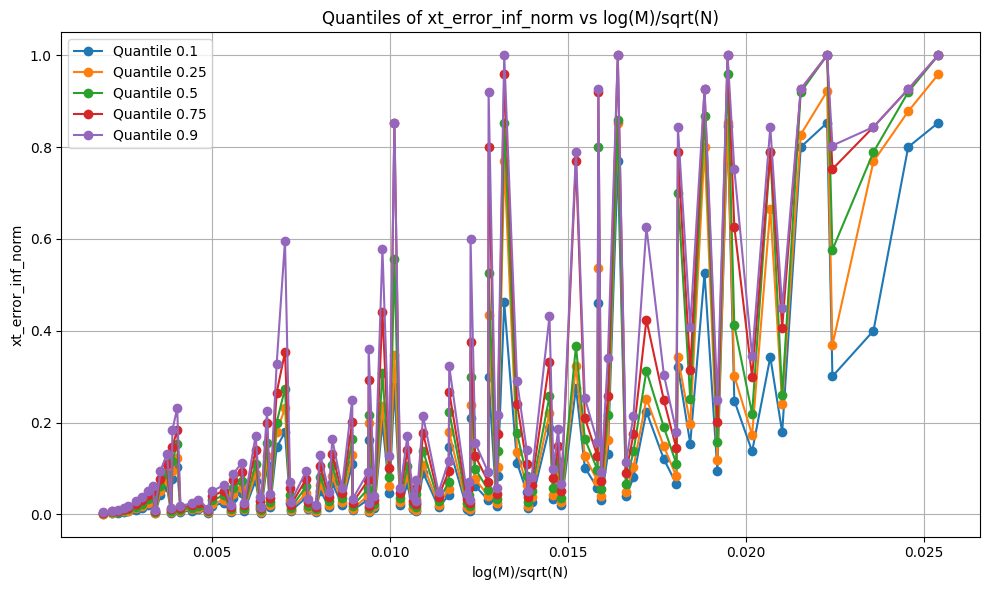

In [131]:
# Define the quantiles to compute
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]

# Group by 'log(M)/sqrt(N)' and compute quantiles for 'xt_error_inf_norm'
grouped = df_errors.groupby('log(M)/sqrt(N)')['xT_error_inf_norm']
quantile_df = grouped.quantile(quantiles).unstack()

# Plotting
plt.figure(figsize=(10, 6))
for q in quantiles:
    plt.plot(quantile_df.index, quantile_df[q], marker='o', label=f'Quantile {q}')

plt.xlabel('log(M)/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title('Quantiles of xt_error_inf_norm vs log(M)/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

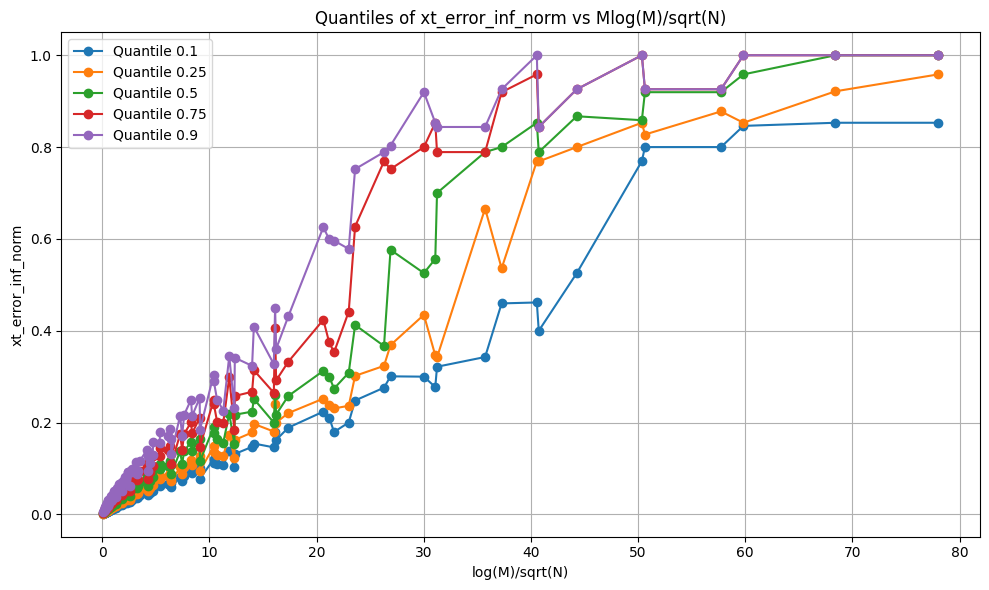

In [132]:
# Define the quantiles to compute
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]

# Group by 'log(M)/sqrt(N)' and compute quantiles for 'xt_error_inf_norm'
grouped = df_errors.groupby('Mlog(M)/sqrt(N)')['xT_error_inf_norm']
quantile_df = grouped.quantile(quantiles).unstack()

# Plotting
plt.figure(figsize=(10, 6))
for q in quantiles:
    plt.plot(quantile_df.index, quantile_df[q], marker='o', label=f'Quantile {q}')

plt.xlabel('log(M)/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title('Quantiles of xt_error_inf_norm vs Mlog(M)/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

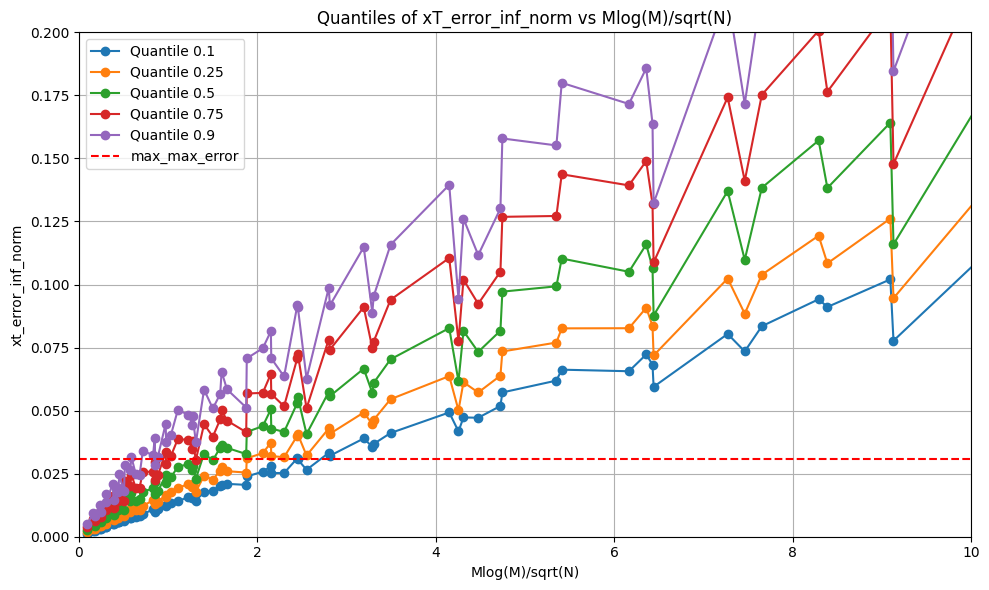

In [133]:
# Define the quantiles to compute
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]

# Group by 'log(M)/sqrt(N)' and compute quantiles for 'xt_error_inf_norm'
grouped = df_errors.groupby('Mlog(M)/sqrt(N)')['xT_error_inf_norm']
quantile_df = grouped.quantile(quantiles).unstack()

# Plotting
plt.figure(figsize=(10, 6))
for q in quantiles:
    plt.plot(quantile_df.index, quantile_df[q], marker='o', label=f'Quantile {q}')

# Add horizontal line at max_max_error
plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')

# Limit axes
plt.ylim(0.0, 0.2)
plt.xlim(0, 10)

plt.xlabel('Mlog(M)/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title('Quantiles of xT_error_inf_norm vs Mlog(M)/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

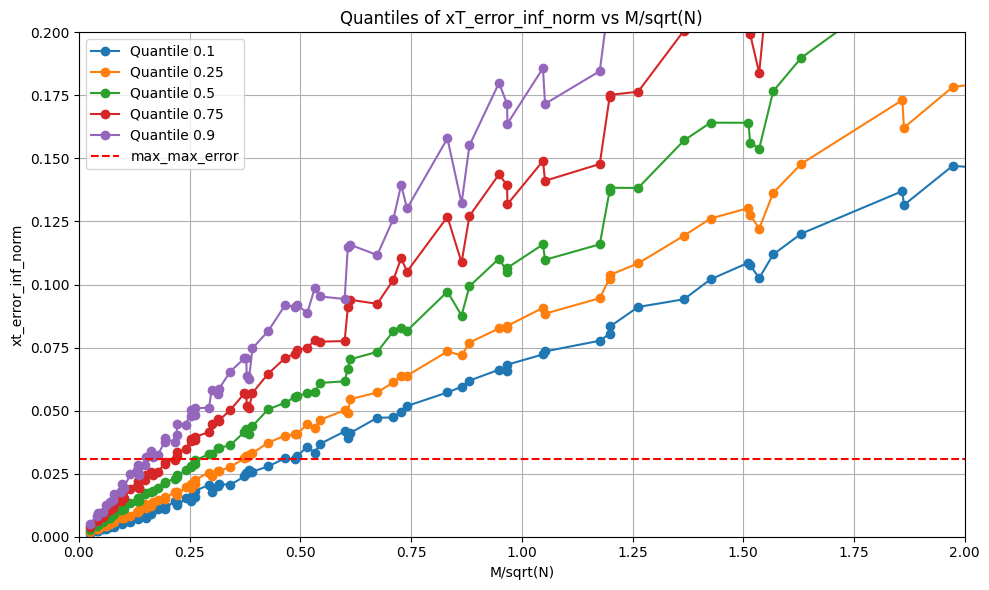

In [134]:
# Define the quantiles to compute
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]

# Group by 'log(M)/sqrt(N)' and compute quantiles for 'xt_error_inf_norm'
grouped = df_errors.groupby('M/sqrt(N)')['xT_error_inf_norm']
quantile_df = grouped.quantile(quantiles).unstack()

# Plotting
plt.figure(figsize=(10, 6))
for q in quantiles:
    plt.plot(quantile_df.index, quantile_df[q], marker='o', label=f'Quantile {q}')

# Add horizontal line at max_max_error
plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')

# Limit axes
plt.ylim(0.0, 0.2)
plt.xlim(0, 2)

plt.xlabel('M/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title('Quantiles of xT_error_inf_norm vs M/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

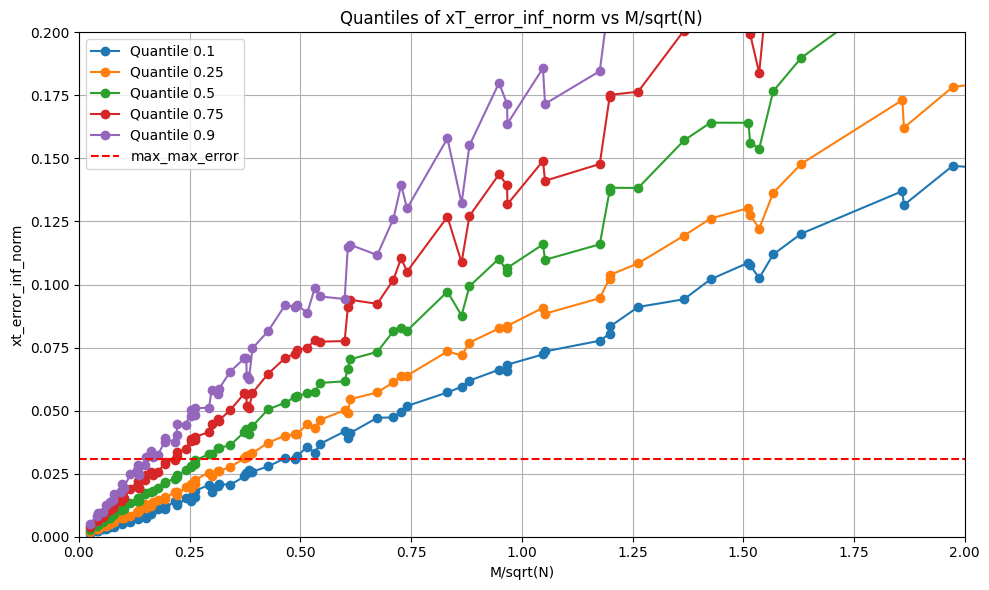

In [135]:
# Define the quantiles to compute
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]

# Group by 'log(M)/sqrt(N)' and compute quantiles for 'xt_error_inf_norm'
grouped = df_errors.groupby('M/sqrt(N)')['xT_error_inf_norm']
quantile_df = grouped.quantile(quantiles).unstack()

# Plotting
plt.figure(figsize=(10, 6))
for q in quantiles:
    plt.plot(quantile_df.index, quantile_df[q], marker='o', label=f'Quantile {q}')

# Add horizontal line at max_max_error
plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')

# Limit axes
plt.ylim(0.0, 0.2)
plt.xlim(0, 2)

plt.xlabel('M/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title('Quantiles of xT_error_inf_norm vs M/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [136]:
df_errors

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,xG_error_inf_norm,prob_shot_error_inf_norm,transition_matrix_error_inf_norm,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N),M/sqrt(N),log(M)/sqrt(N)
0,16,12,4000000,0,5176042,0.000561,0.000314,0.007967,0.000580,0.000403,...,0.500000,0.022223,0.131414,1.0,1.0,192,0.000500,0.504720,0.096000,0.002629
1,16,12,4000000,1,5176043,0.000338,0.000166,0.006788,0.000344,0.000401,...,0.500000,0.008385,0.117864,1.0,1.0,192,0.000500,0.504720,0.096000,0.002629
2,16,12,4000000,2,5176044,0.000370,0.000248,0.009014,0.000351,0.000414,...,0.500000,0.006650,0.132075,1.0,1.0,192,0.000500,0.504720,0.096000,0.002629
3,16,12,4000000,3,5176045,0.000605,0.000350,0.005589,0.000430,0.000438,...,0.157143,0.011811,0.133729,1.0,1.0,192,0.000500,0.504720,0.096000,0.002629
4,16,12,4000000,4,5176046,0.000337,0.000259,0.008731,0.000483,0.000433,...,0.500000,0.012102,0.139206,1.0,1.0,192,0.000500,0.504720,0.096000,0.002629
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103995,28,21,100000,995,2159037,0.004289,0.003060,0.020488,0.004061,0.002459,...,1.000000,0.141115,1.485828,1.0,1.0,588,0.003162,11.857009,1.859419,0.020165
103996,28,21,100000,996,2159038,0.004707,0.003015,0.020488,0.004709,0.002280,...,1.000000,0.182749,1.333076,1.0,1.0,588,0.003162,11.857009,1.859419,0.020165
103997,28,21,100000,997,2159039,0.003862,0.003023,0.020745,0.005296,0.002284,...,1.000000,0.398693,1.340164,1.0,1.0,588,0.003162,11.857009,1.859419,0.020165
103998,28,21,100000,998,2159040,0.004451,0.003073,0.017595,0.005439,0.002383,...,1.000000,0.315829,1.550351,1.0,1.0,588,0.003162,11.857009,1.859419,0.020165


In [137]:
np.sum(df_errors['xT_error_inf_norm'] < max_max_error)

np.int64(31486)

In [138]:
per_Z_val = df_errors.groupby('Mlog(M)/sqrt(N)')['xT_error_inf_norm'].apply(lambda x: np.sum(x < max_max_error) / len(x))
per_Z_val = per_Z_val.reset_index()
per_Z_val.columns = ['Mlog(M)/sqrt(N)', 'percentage']
per_Z_val['percentage'] = per_Z_val['percentage'] * 100
per_Z_val['percentage'] = per_Z_val['percentage'].round(2)

per_Z_val

,Mlog(M)/sqrt(N),percentage
0,0.092909,100.0
1,0.162973,100.0
2,0.175281,100.0
3,0.234108,100.0
4,0.252835,100.0
...,...,...
99,50.640317,0.0
100,57.738845,0.0
101,59.829703,0.0
102,68.417882,0.0


# Check filtering on MlogM/sqrtN instead of MsqrtlogM/sqrtN

In [139]:
df_errors_sorted = df_errors.sort_values(by='Mlog(M)/sqrt(N)')
df_errors_sorted['Msqrtlog(M)/sqrt(N)'] = df_errors_sorted['M'] * np.sqrt(np.log(df_errors_sorted['M'])) * df_errors_sorted['1/sqrt(N)']

Text(0.5, 1.0, '$M\\sqrt{\\log(M)}/sqrt{N}$ vs $M\\log(M)/\\sqrt{N}$')

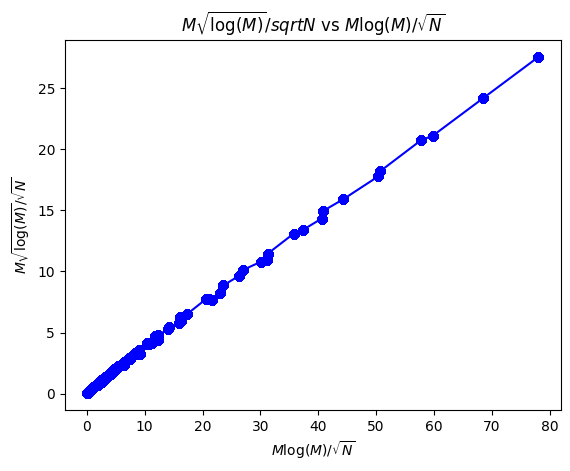

In [140]:
plt.plot(df_errors_sorted['Mlog(M)/sqrt(N)'], df_errors_sorted['Msqrtlog(M)/sqrt(N)'], marker='o', linestyle='-', color='blue')
plt.xlabel(r'$M\log(M)/\sqrt{N}$')
plt.ylabel(r'$M\sqrt{\log(M)}/\sqrt{N}$')
plt.title(r'$M\sqrt{\log(M)}/sqrt{N}$ vs $M\log(M)/\sqrt{N}$')

In [141]:
df_errors['M'].max()

np.int64(3072)

In [142]:
print(np.sqrt(np.log(192)))
print(np.sqrt(np.log(3072)))
print(np.sqrt(np.log(3072))/np.sqrt(np.log(192)))

2.292922888373654
2.8337403011333913
1.235863759528055


In [143]:
print(np.log(192))
print(np.log(3072))
print(np.log(3072)/np.log(192))

5.2574953720277815
8.030084094267563
1.5273592321148182


In [144]:
df_errors_sorted.groupby('Mlog(M)/sqrt(N)')['Msqrtlog(M)/sqrt(N)'].first().reset_index()

,Mlog(M)/sqrt(N),Msqrtlog(M)/sqrt(N)
0,0.092909,0.047221
1,0.162973,0.082831
2,0.175281,0.083733
3,0.234108,0.118985
4,0.252835,0.116846
...,...,...
99,50.640317,18.175277
100,57.738845,20.723004
101,59.829703,21.113333
102,68.417882,24.144020


In [145]:
df_errors_sorted['Msqrtlog(M)/sqrt(N)'].unique().tolist()

[0.0472208829045259,
 0.08283090806034527,
 0.08373316317611683,
 0.11898544081359703,
 0.11684645761979362,
 0.1552613065833783,
 0.1468776844911146,
 0.1927784471996695,
 0.1728123027440767,
 0.21098773928837752,
 0.20496224536611782,
 0.22905492700033353,
 0.2201205972838708,
 0.2619343301306908,
 0.27531294460055683,
 0.2986510862048183,
 0.2944253985150686,
 0.30313283191321316,
 0.3418392072178138,
 0.38418878605824835,
 0.4061655013437751,
 0.3582388947054249,
 0.38611707012494384,
 0.4644680204435114,
 0.43544607290783977,
 0.47702366570038957,
 0.5295750226541356,
 0.5667885726419607,
 0.5546517703391637,
 0.5682033513006604,
 0.5320981716235429,
 0.6481475296992243,
 0.6283925908581587,
 0.7055032716639283,
 0.7390018852017692,
 0.7237520655703746,
 0.7424141502346018,
 0.8382627972000526,
 0.8986385753702468,
 0.9585901824227303,
 0.9026771669916264,
 0.9333619369620724,
 1.0677417329122907,
 1.0929609687396966,
 0.9897811166571239,
 1.2210093850657775,
 1.1778822300592475,


In [146]:
# Check number of times that the MsqrtlogM/sqrt(N) is not increasing
non_increasing_count = np.sum(df_errors_sorted['Msqrtlog(M)/sqrt(N)'].diff() < -0.00001)
print(f'Number of times Msqrtlog(M)/sqrt(N) is not increasing: {non_increasing_count} out of {len(df_errors_sorted)}')


Number of times Msqrtlog(M)/sqrt(N) is not increasing: 28 out of 104000


In [147]:
# Find these situations
non_increasing_indices = df_errors_sorted.index[df_errors_sorted['Msqrtlog(M)/sqrt(N)'].diff() < -0.00001].tolist()
print(f'Indices where Msqrtlog(M)/sqrt(N) is not increasing: {non_increasing_indices}')

Indices where Msqrtlog(M)/sqrt(N) is not increasing: [64063, 57943, 72951, 65952, 9, 66972, 80992, 74032, 2039, 88955, 81007, 3003, 82960, 8940, 83000, 97035, 16055, 9000, 10996, 24988, 17956, 11035, 32040, 12008, 18984, 40103, 26007, 41006]


In [148]:
df_errors_sorted.loc[8959-5:8959+5]

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,prob_shot_error_inf_norm,transition_matrix_error_inf_norm,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N),M/sqrt(N),log(M)/sqrt(N),Msqrtlog(M)/sqrt(N)
8954,32,24,4000000,954,6352996,0.000753,0.000503,0.006542,0.000914,0.000441,...,0.048245,0.423786,1.0,1.0,768,0.0005,2.551215,0.384,0.003322,0.989781
8955,32,24,4000000,955,6352997,0.000807,0.000457,0.005724,0.000837,0.000416,...,0.030682,0.447019,1.0,1.0,768,0.0005,2.551215,0.384,0.003322,0.989781
8956,32,24,4000000,956,6352998,0.000639,0.000386,0.006279,0.000805,0.000431,...,0.027204,0.468190,1.0,1.0,768,0.0005,2.551215,0.384,0.003322,0.989781
8957,32,24,4000000,957,6352999,0.000673,0.000442,0.005686,0.000855,0.000419,...,0.034975,0.440947,1.0,1.0,768,0.0005,2.551215,0.384,0.003322,0.989781
8958,32,24,4000000,958,6353000,0.000742,0.000553,0.006269,0.000782,0.000417,...,0.027163,0.435503,1.0,1.0,768,0.0005,2.551215,0.384,0.003322,0.989781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8928,32,24,4000000,928,6352970,0.000820,0.000594,0.006023,0.000815,0.000422,...,0.033336,0.432853,1.0,1.0,768,0.0005,2.551215,0.384,0.003322,0.989781
8929,32,24,4000000,929,6352971,0.000696,0.000539,0.004828,0.000824,0.000421,...,0.033852,0.475013,1.0,1.0,768,0.0005,2.551215,0.384,0.003322,0.989781
8930,32,24,4000000,930,6352972,0.000631,0.000416,0.006688,0.000727,0.000408,...,0.030225,0.396121,1.0,1.0,768,0.0005,2.551215,0.384,0.003322,0.989781
8931,32,24,4000000,931,6352973,0.000722,0.000510,0.006273,0.000945,0.000431,...,0.042869,0.426771,1.0,1.0,768,0.0005,2.551215,0.384,0.003322,0.989781


In [149]:
df_errors_sorted.iloc[non_increasing_indices]

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,prob_shot_error_inf_norm,transition_matrix_error_inf_norm,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N),M/sqrt(N),log(M)/sqrt(N),Msqrtlog(M)/sqrt(N)
17923,40,30,1300000,923,4240965,0.001300,0.000924,0.011008,0.001748,0.000726,...,0.081145,1.136364,1.0,1.0,1200,0.000877,7.462090,1.052470,0.006218,2.802432
92967,24,18,240000,967,2005009,0.002415,0.001571,0.019895,0.003269,0.001746,...,0.116928,0.997560,1.0,1.0,432,0.002041,5.351237,0.881816,0.012387,2.172282
18943,40,30,630000,943,3570985,0.002214,0.001487,0.013450,0.002556,0.000979,...,0.086176,1.241509,1.0,1.0,1200,0.001260,10.719189,1.511858,0.008933,4.025654
100047,28,21,240000,47,2298089,0.002240,0.001496,0.015715,0.003347,0.001646,...,0.141865,1.205226,1.0,1.0,588,0.002041,7.653666,1.200250,0.013016,3.030893
48022,8,6,4000000,22,4588064,0.000248,0.000139,0.024111,0.000120,0.000347,...,0.001493,0.026256,1.0,1.0,48,0.000500,0.092909,0.024000,0.001936,0.047221
95947,24,18,100000,947,1864989,0.003185,0.002358,0.018018,0.003569,0.002744,...,0.111381,1.298341,1.0,1.0,432,0.003162,8.290100,1.366104,0.019190,3.365284
15983,32,24,100000,983,2453025,0.004597,0.003062,0.019111,0.004739,0.002142,...,0.144654,1.439759,1.0,1.0,768,0.003162,16.135302,2.428629,0.021010,6.259925
103023,28,21,100000,23,2158065,0.004043,0.002984,0.018873,0.004233,0.002386,...,0.142527,1.439831,1.0,1.0,588,0.003162,11.857009,1.859419,0.020165,4.695439
56912,10,8,4000000,912,4756954,0.000106,0.000037,0.009345,0.000230,0.000399,...,0.005606,0.048738,1.0,1.0,80,0.000500,0.175281,0.040000,0.002191,0.083733
28940,48,36,240000,940,3768982,0.003943,0.002737,0.017046,0.005449,0.001337,...,0.354212,1.681529,1.0,1.0,1728,0.002041,26.294774,3.527265,0.015217,9.630610


In [150]:
df_errors_sorted

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,prob_shot_error_inf_norm,transition_matrix_error_inf_norm,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N),M/sqrt(N),log(M)/sqrt(N),Msqrtlog(M)/sqrt(N)
48935,8,6,4000000,935,4588977,0.000239,0.000126,0.014694,0.000243,0.000430,...,0.002824,0.030979,1.0,1.0,48,0.000500,0.092909,0.024000,0.001936,0.047221
48934,8,6,4000000,934,4588976,0.000246,0.000065,0.013983,0.000208,0.000370,...,0.003117,0.030062,1.0,1.0,48,0.000500,0.092909,0.024000,0.001936,0.047221
48933,8,6,4000000,933,4588975,0.000139,0.000066,0.013513,0.000184,0.000348,...,0.003582,0.030326,1.0,1.0,48,0.000500,0.092909,0.024000,0.001936,0.047221
48932,8,6,4000000,932,4588974,0.000154,0.000066,0.016583,0.000252,0.000385,...,0.003215,0.021932,1.0,1.0,48,0.000500,0.092909,0.024000,0.001936,0.047221
48931,8,6,4000000,931,4588973,0.000239,0.000094,0.010421,0.000278,0.000420,...,0.004448,0.020761,1.0,1.0,48,0.000500,0.092909,0.024000,0.001936,0.047221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47990,64,48,100000,990,4805032,0.009341,0.006219,0.023038,0.012435,0.001145,...,1.000000,1.884615,1.0,1.0,3072,0.003162,78.008388,9.714517,0.025393,27.528418
47991,64,48,100000,991,4805033,0.008254,0.005793,0.021317,0.012244,0.001220,...,1.000000,1.906250,1.0,1.0,3072,0.003162,78.008388,9.714517,0.025393,27.528418
47992,64,48,100000,992,4805034,0.008248,0.005697,0.022721,0.011968,0.001138,...,1.000000,1.903614,1.0,1.0,3072,0.003162,78.008388,9.714517,0.025393,27.528418
47983,64,48,100000,983,4805025,0.009499,0.006679,0.021331,0.012735,0.001084,...,1.000000,1.883117,1.0,1.0,3072,0.003162,78.008388,9.714517,0.025393,27.528418


# OLS modeling

In [151]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

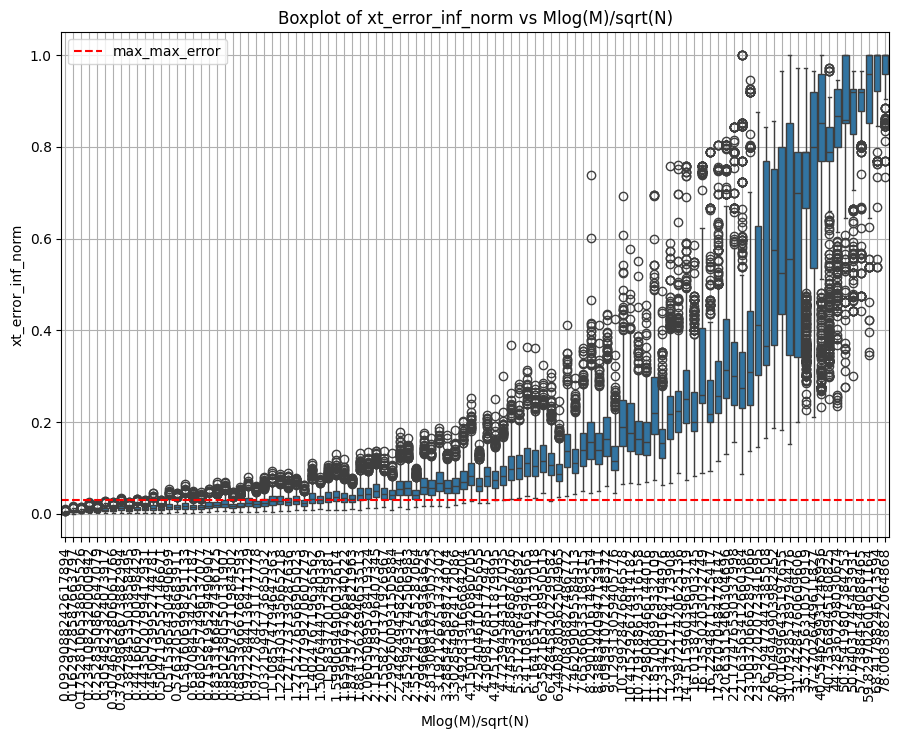

In [152]:
# Plot a boxplot of the errors for each value of Mlog(M)/sqrt(N)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Mlog(M)/sqrt(N)', y='xT_error_inf_norm', data=df_errors)
plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')
plt.xlabel('Mlog(M)/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title('Boxplot of xt_error_inf_norm vs Mlog(M)/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.xticks(rotation=90)

# current_values = plt.gca().get_xticks()
# plt.gca().set_xticklabels(['{:.2f}'.format(x) for x in current_values])

plt.show()

In [153]:
df_errors_ols = df_errors[df_errors['Mlog(M)/sqrt(N)'] < 15].copy()
df_errors_ols['sqrt(M)log(M)/sqrt(N)'] = df_errors_ols['log(M)/sqrt(N)'] * np.sqrt(df_errors_ols['M'])

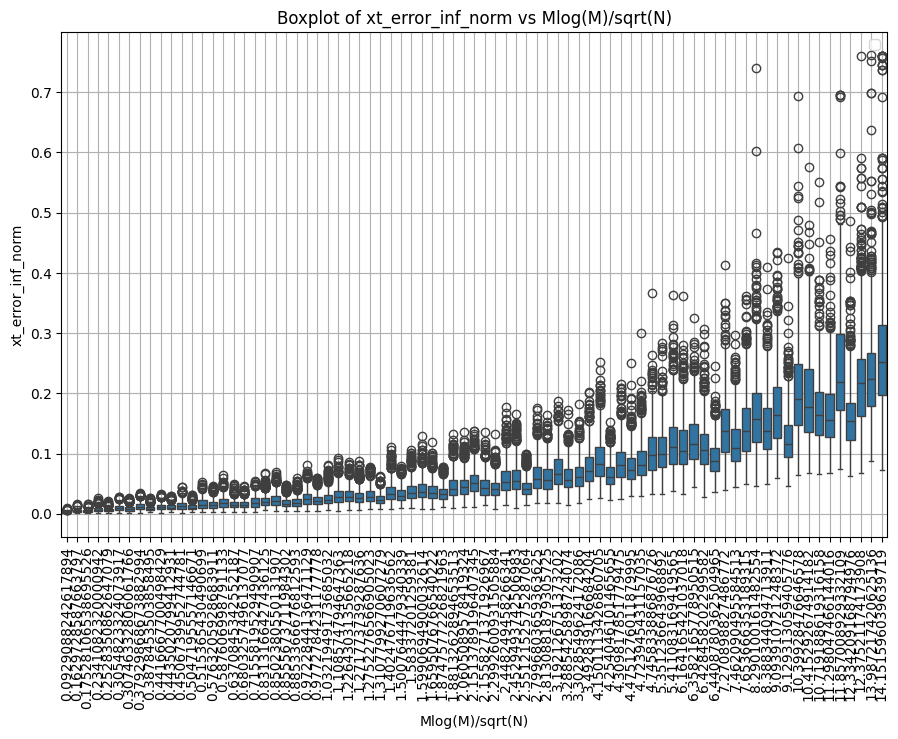

In [154]:
# Plot a boxplot of the errors for each value of Mlog(M)/sqrt(N)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Mlog(M)/sqrt(N)', y='xT_error_inf_norm', data=df_errors_ols)
# plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')
plt.xlabel('Mlog(M)/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title('Boxplot of xt_error_inf_norm vs Mlog(M)/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.xticks(rotation=90)

plt.show()

In [155]:
# Specify seaborn blue
color = sns.color_palette("tab10")[0]
color

(0.12156862745098039, 0.4666666666666667, 0.7058823529411765)

14.151596039639719
[ 0.     1.875  3.75   5.625  7.5    9.375 11.25  13.125 15.   ]


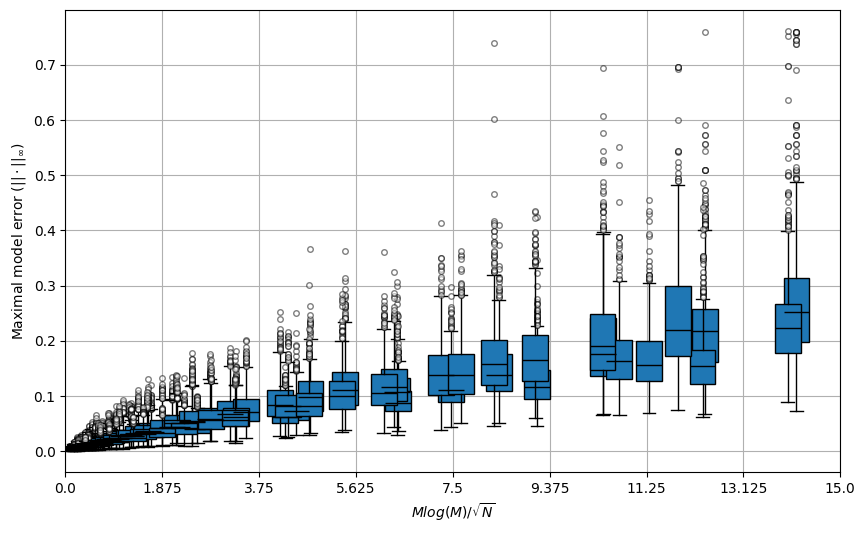

In [156]:
plt.figure(figsize=(10, 6))

vals = df_errors_ols['Mlog(M)/sqrt(N)'].unique().tolist()
data_listed = [
    df_errors_ols[df_errors_ols['Mlog(M)/sqrt(N)'] == val]['xT_error_inf_norm'].tolist()
    for val in vals
]


plt.boxplot(
    data_listed,
    positions=vals,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1),
    # boxprops=dict(facecolor='lightblue', color='black', linewidth=1),
    boxprops=dict(facecolor=color, color='black', linewidth=1),
    # boxprops=dict(facecolor='#4C72B0', color='black'),
    capprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    flierprops=dict(markerfacecolor='white', marker='o', markersize=4, alpha=0.5),
)

plt.grid(True)
plt.xlim(0, np.ceil(max(vals)))
n_ticks = 9
ticks = np.linspace(0.0, np.ceil(max(vals)), n_ticks)
print(max(vals))
print(ticks)
plt.xticks(ticks, labels=ticks)
plt.xlabel(r'$Mlog(M)/\sqrt{N}$')
plt.ylabel(r'Maximal model error ($||\cdot||_{\infty}$)')
plt.show()

14.151596039639719
[ 0.     1.875  3.75   5.625  7.5    9.375 11.25  13.125 15.   ]


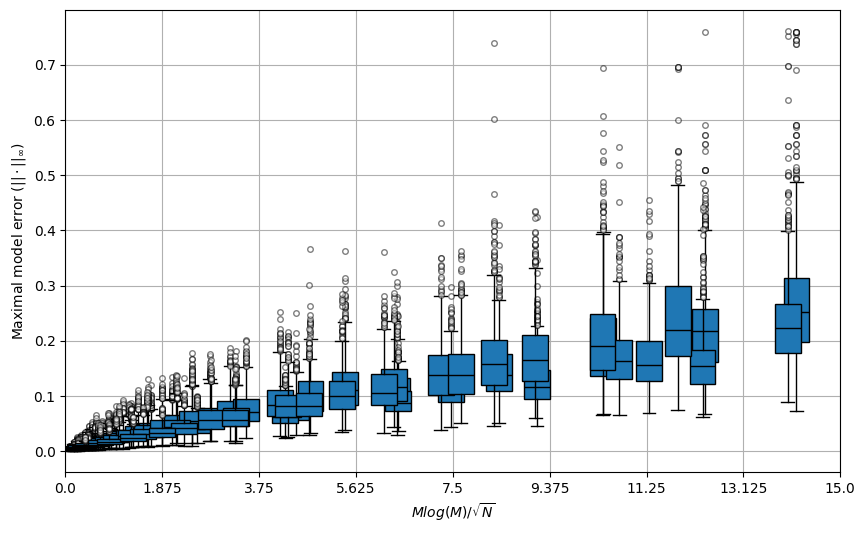

In [157]:
plt.figure(figsize=(10, 6))

vals = df_errors_ols['Mlog(M)/sqrt(N)'].unique().tolist()
data_listed = [
    df_errors_ols[df_errors_ols['Mlog(M)/sqrt(N)'] == val]['xT_error_inf_norm'].tolist()
    for val in vals
]

for idx, (val, data_points) in enumerate(zip(vals, data_listed)):
    plt.boxplot(
        data_points,
        positions=[val],
        widths=0.5,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1),
        # boxprops=dict(facecolor='lightblue', color='black', linewidth=1),
        boxprops=dict(facecolor=color, color='black', linewidth=1),
        # boxprops=dict(facecolor='#4C72B0', color='black'),
        capprops=dict(color='black'),
        whiskerprops=dict(color='black'),
        flierprops=dict(markerfacecolor='white', marker='o', markersize=4, alpha=0.5),
        zorder=idx,
    )

plt.grid(True)
plt.xlim(0, np.ceil(max(vals)))
n_ticks = 9
ticks = np.linspace(0.0, np.ceil(max(vals)), n_ticks)
print(max(vals))
print(ticks)
plt.xticks(ticks, labels=ticks)
plt.xlabel(r'$Mlog(M)/\sqrt{N}$')
plt.ylabel(r'Maximal model error ($||\cdot||_{\infty}$)')
plt.show()

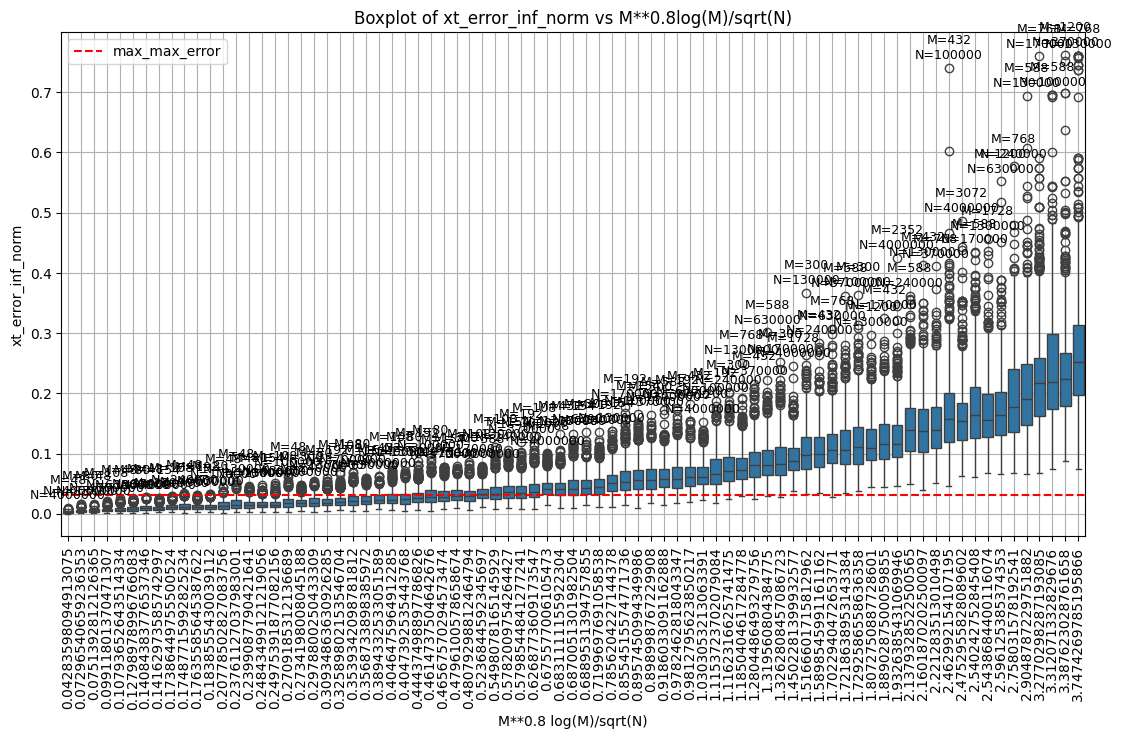

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns

power = 0.8

df_errors_ols[f'M**{power} log(M)/sqrt(N)'] = df_errors_ols['M']**power * df_errors_ols['log(M)/sqrt(N)']

# Create the boxplot
plt.figure(figsize=(12, 6))
ax = sns.boxplot(x=f'M**{power} log(M)/sqrt(N)', y='xT_error_inf_norm', data=df_errors_ols)

# Add a red dashed line for max_max_error
plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')

# Set labels and title
plt.xlabel(f'M**{power} log(M)/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title(f'Boxplot of xt_error_inf_norm vs M**{power}log(M)/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=90)

# Annotate each box with M and N
grouped = df_errors_ols.groupby(f'M**{power} log(M)/sqrt(N)')
for i, (name, group) in enumerate(grouped):
    # Use the first row as a representative for M and N
    M = group['M'].iloc[0]
    N = group['N'].iloc[0]
    ax.text(i, group['xT_error_inf_norm'].max() + 0.01, f'M={M}\nN={N}',
            ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.show()


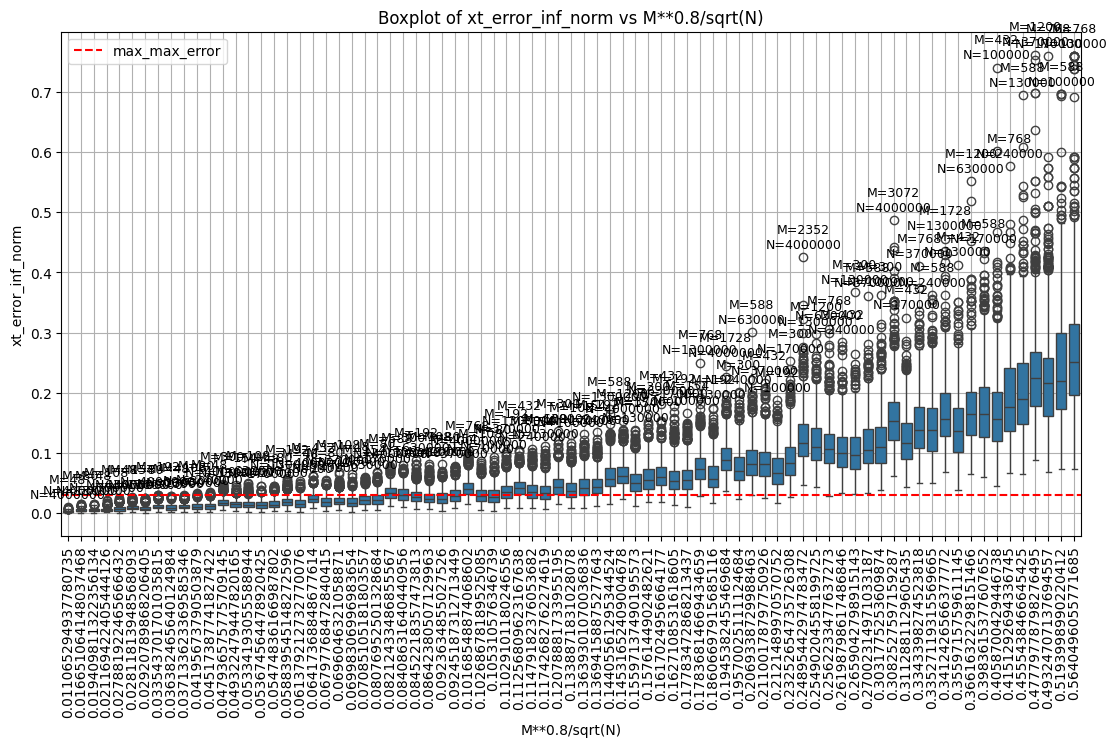

In [159]:
import matplotlib.pyplot as plt
import seaborn as sns

power = 0.8

df_errors_ols[f'M**{power}/sqrt(N)'] = df_errors_ols['M']**power * df_errors_ols['1/sqrt(N)']

# Create the boxplot
plt.figure(figsize=(12, 6))
ax = sns.boxplot(x=f'M**{power}/sqrt(N)', y='xT_error_inf_norm', data=df_errors_ols)

# Add a red dashed line for max_max_error
plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')

# Set labels and title
plt.xlabel(f'M**{power}/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title(f'Boxplot of xt_error_inf_norm vs M**{power}/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=90)

# Annotate each box with M and N
grouped = df_errors_ols.groupby(f'M**{power}/sqrt(N)')
for i, (name, group) in enumerate(grouped):
    # Use the first row as a representative for M and N
    M = group['M'].iloc[0]
    N = group['N'].iloc[0]
    ax.text(i, group['xT_error_inf_norm'].max() + 0.01, f'M={M}\nN={N}',
            ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.show()


## Seperate log(M) and sqrt(N) (or leave out log(M) at all as it doesn't seem to make such a difference...)

                            OLS Regression Results                            
Dep. Variable:      xT_error_inf_norm   R-squared:                       0.870
Model:                            OLS   Adj. R-squared:                  0.870
Method:                 Least Squares   F-statistic:                 2.651e+05
Date:                 do, 08 jan 2026   Prob (F-statistic):               0.00
Time:                        16:49:10   Log-Likelihood:                -43294.
No. Observations:               79000   AIC:                         8.659e+04
Df Residuals:                   78997   BIC:                         8.662e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.0550      0.016   -125.

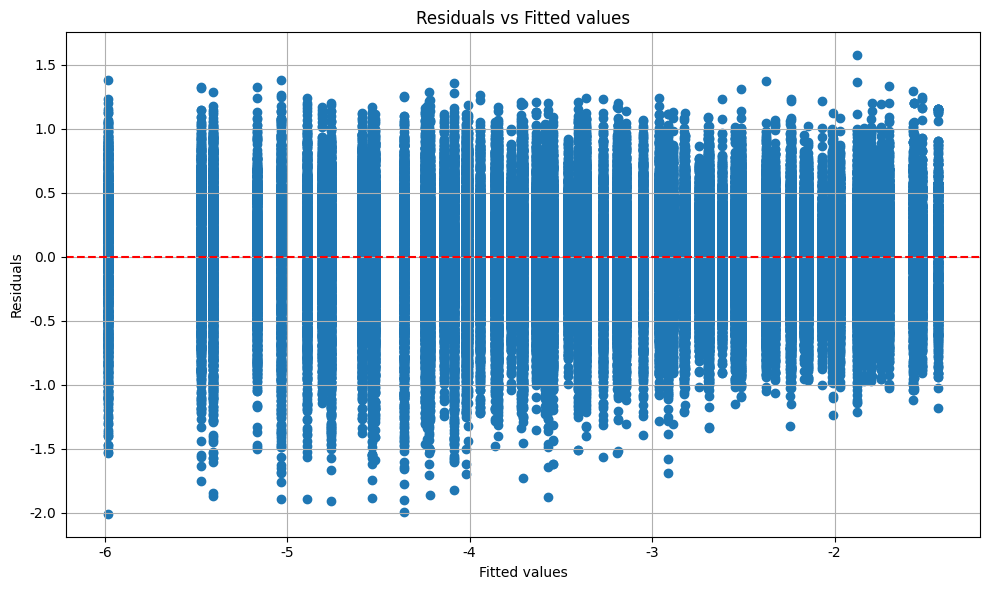

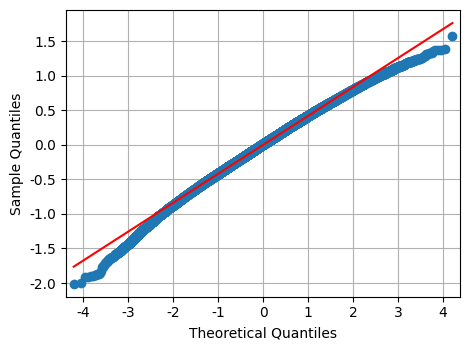

In [160]:
log_y = np.log(df_errors_ols['xT_error_inf_norm'])
log_x = np.log(df_errors_ols[f'log(M)/sqrt(N)'])
log_M = np.log(df_errors_ols['M'])

# Do OLS regression on log transformations

X = sm.add_constant(pd.DataFrame({
    # 'log(log(M))': np.log(np.log(df_errors_ols['M'])), 
    'log(M)': np.log(df_errors_ols['M']),
    'log(1/sqrt(N))': -np.log(np.sqrt(df_errors_ols['N']))
    }))
# X = sm.add_constant(np.array([log_x, log_M]).T)
Y = log_y
# Fit the model
model = sm.OLS(Y,X)
results = model.fit()
print(results.summary())

# Plot the residuals and values
plt.figure(figsize=(10, 6))
plt.scatter(results.fittedvalues, results.resid)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted values')
plt.grid(True)
plt.tight_layout()
plt.show()


# Plot the QQ plot of the residuals
# fig, ax = plt.subplots(figsize=(6.4, 4.8))
fig, ax = plt.subplots(figsize=(4.8, 3.6))
# fig, ax = plt.subplots(figsize=(3.2, 2.4))
sm.qqplot(results.resid, line='s', ax = ax)
# plt.title('QQ plot of residuals')
plt.grid(True)
plt.tight_layout()
plt.show()


In [161]:
c = results.params['const']
power = results.params['log(M)']
std_residuals = np.sqrt(results.mse_resid)
beta = results.params['log(1/sqrt(N))']
print(f"c={c}")
print(f"power={power}")
print(f"std_residuals={std_residuals}")
print(f"beta={beta}")

c=-2.0549618693866707
power=1.006356015220525
std_residuals=0.41857836237825136
beta=1.0294922965295545


                    coef  ci_lower  ci_upper varname
log(1/sqrt(N))  1.029492  1.024599  1.034386  \alpha
log(M)          1.006356  1.003471  1.009241   \beta


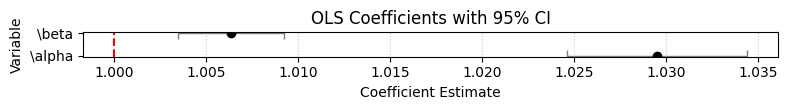

In [162]:
# Extract coefficients and confidence intervals
coefs = results.params
conf = results.conf_int()
conf.columns = ['ci_lower', 'ci_upper']
summary_df = pd.concat([coefs, conf], axis=1)
summary_df.columns = ['coef', 'ci_lower', 'ci_upper']
summary_df['varname'] = summary_df.index

# Optional: sort by absolute value of coefficients for clarity
summary_df = summary_df.reindex(summary_df.coef.abs().sort_values(ascending=False).index)
summary_df = summary_df.iloc[1:]
summary_df['varname'] = [r'\alpha', r'\beta']
print(summary_df)

# Plot
plt.figure(figsize=(8, len(summary_df) * 0.6))
plt.errorbar(
    summary_df['coef'],
    summary_df['varname'],
    xerr=[summary_df['coef'] - summary_df['ci_lower'], summary_df['ci_upper'] - summary_df['coef']],
    fmt='o',
    color='black',
    ecolor='gray',
    capsize=4,
    elinewidth=1
)
plt.axvline(x=1, color='red', linestyle='--')
plt.title('OLS Coefficients with 95% CI')
plt.xlabel('Coefficient Estimate')
plt.ylabel('Variable')
plt.grid(True, axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

                    coef  ci_lower  ci_upper   varname
log(1/sqrt(N))  1.029492  1.024599  1.034386  $\alpha$
log(M)          1.006356  1.003471  1.009241   $\beta$


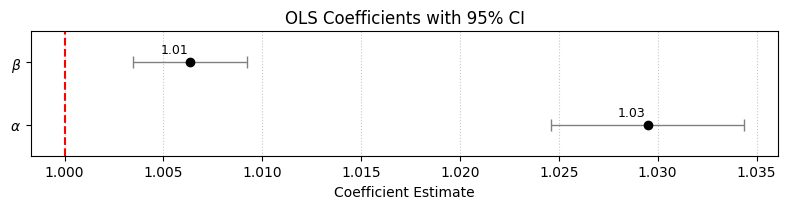

In [163]:
import matplotlib.pyplot as plt

# Extract coefficients and confidence intervals
coefs = results.params
conf = results.conf_int()
conf.columns = ['ci_lower', 'ci_upper']
summary_df = pd.concat([coefs, conf], axis=1)
summary_df.columns = ['coef', 'ci_lower', 'ci_upper']
summary_df['varname'] = summary_df.index

# Optional: sort by absolute value of coefficients for clarity
summary_df = summary_df.reindex(summary_df.coef.abs().sort_values(ascending=False).index)
summary_df = summary_df.iloc[1:]
summary_df['varname'] = [r'$\alpha$', r'$\beta$']
print(summary_df)

# Plot
plt.figure(figsize=(8, len(summary_df) * 0.6 + 1))  # Add space to figure height
y_positions = range(len(summary_df))

plt.errorbar(
    summary_df['coef'],
    y_positions,
    xerr=[summary_df['coef'] - summary_df['ci_lower'], summary_df['ci_upper'] - summary_df['coef']],
    fmt='o',
    color='black',
    ecolor='gray',
    capsize=4,
    elinewidth=1
)

# Annotate coefficients
for i, (coef, varname) in enumerate(zip(summary_df['coef'], summary_df['varname'])):
    plt.text(coef-0.0015, i+0.2, f"{coef:.2f}", va='center', ha='left', fontsize=9, color='black')

# Red line at x=1 (you may want x=0 for significance thresholds)
plt.axvline(x=1, color='red', linestyle='--')
plt.title('OLS Coefficients with 95% CI')
plt.xlabel('Coefficient Estimate')
plt.yticks(ticks=y_positions, labels=summary_df['varname'])
plt.grid(True, axis='x', linestyle=':', alpha=0.7)

# Add vertical padding
plt.ylim(-0.5, len(summary_df) - 0.5)

plt.tight_layout()
plt.show()


<>:49: SyntaxWarning: invalid escape sequence '\s'
<>:49: SyntaxWarning: invalid escape sequence '\s'
C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_20360\1322688307.py:49: SyntaxWarning: invalid escape sequence '\s'
  f'$\sigma^2$={resid_var:.3f}, $n$={n_obs}', fontsize=11)


                    coef  ci_lower  ci_upper   varname
log(1/sqrt(N))  1.029492  1.024599  1.034386  $\alpha$
log(M)          1.006356  1.003471  1.009241   $\beta$


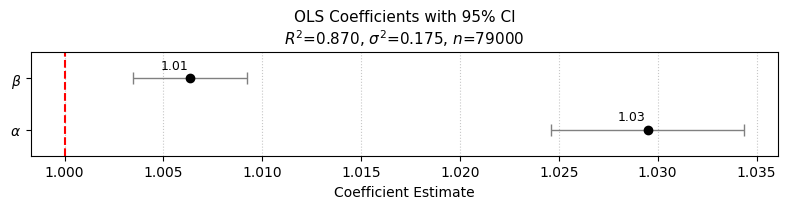

In [164]:
import matplotlib.pyplot as plt

# Enable LaTeX-style rendering in plot labels (using mathtext)
plt.rcParams['axes.unicode_minus'] = False  # Ensure minus sign is rendered correctly

# Extract coefficients and confidence intervals
coefs = results.params
conf = results.conf_int()
conf.columns = ['ci_lower', 'ci_upper']
summary_df = pd.concat([coefs, conf], axis=1)
summary_df.columns = ['coef', 'ci_lower', 'ci_upper']
summary_df['varname'] = summary_df.index

# Optional: sort by absolute value of coefficients for clarity
summary_df = summary_df.reindex(summary_df.coef.abs().sort_values(ascending=False).index)
summary_df = summary_df.iloc[1:]
summary_df['varname'] = [r'$\alpha$', r'$\beta$']
print(summary_df)

# Extract model summary info
r_squared = results.rsquared
resid_var = results.mse_resid
n_obs = int(results.nobs)

# Plot
plt.figure(figsize=(8, len(summary_df) * 0.6 + 1))
y_positions = range(len(summary_df))

plt.errorbar(
    summary_df['coef'],
    y_positions,
    xerr=[summary_df['coef'] - summary_df['ci_lower'], summary_df['ci_upper'] - summary_df['coef']],
    fmt='o',
    color='black',
    ecolor='gray',
    capsize=4,
    elinewidth=1
)

# Annotate coefficients
for i, (coef, varname) in enumerate(zip(summary_df['coef'], summary_df['varname'])):
    plt.text(coef-0.0015, i+0.25, f"{coef:.2f}", va='center', ha='left', fontsize=9, color='black')

# Red vertical line at x = 1 (or 0 if checking significance)
plt.axvline(x=1, color='red', linestyle='--')

# Labels and layout
plt.title(f'OLS Coefficients with 95% CI\n$R^2$={r_squared:.3f}, '
          f'$\sigma^2$={resid_var:.3f}, $n$={n_obs}', fontsize=11)
plt.xlabel('Coefficient Estimate')
plt.yticks(ticks=y_positions, labels=summary_df['varname'])
plt.grid(True, axis='x', linestyle=':', alpha=0.7)
plt.ylim(-0.5, len(summary_df) - 0.5)

# # Add model summary text box
# stats_text = f"$R^2$ = {r_squared:.3f}\n" \
#              f"$\\sigma^2$ = {resid_var:.3f}\n" \
#              f"$n$ = {n_obs}"
# plt.text(0.99, -1.2, stats_text, ha='right', va='top', fontsize=10,
#          bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.4'),
#          transform=plt.gca().transData)

plt.tight_layout()
plt.show()


                    coef  ci_lower  ci_upper   varname
log(1/sqrt(N))  1.029492  1.024599  1.034386   $\beta$
log(M)          1.006356  1.003471  1.009241  $\alpha$


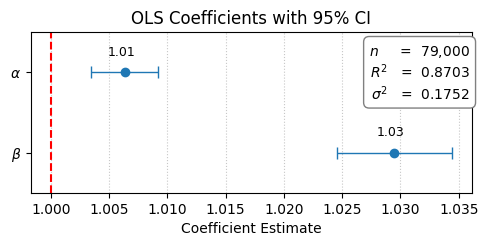

In [165]:
# Extract coefficients and confidence intervals
coefs = results.params
conf = results.conf_int()
conf.columns = ['ci_lower', 'ci_upper']
summary_df = pd.concat([coefs, conf], axis=1)
summary_df.columns = ['coef', 'ci_lower', 'ci_upper']
summary_df['varname'] = summary_df.index

# Optional: sort by absolute value of coefficients for clarity
summary_df = summary_df.reindex(summary_df.coef.abs().sort_values(ascending=False).index)
summary_df = summary_df.iloc[1:]
summary_df['varname'] = [r'$\beta$', r'$\alpha$']
print(summary_df)

# Extract model statistics
r_squared = results.rsquared
resid_var = results.mse_resid
n_obs = int(results.nobs)
stats_text = f"$R^2$   =  {r_squared:.4f}\n" \
             f"$\\sigma^2$   =  {resid_var:.4f}\n" \
             f"$n$    =  {n_obs:,}"
stats_text = f"$n$     =  {n_obs:,}\n" \
             f"$R^2$   =  {r_squared:.4f}\n" \
             f"$\\sigma^2$   =  {resid_var:.4f}"

# Create plot
fig, ax = plt.subplots(figsize=(5, len(summary_df) * 0.6 + 1.5))
y_positions = range(len(summary_df))

# Error bars
ax.errorbar(
    summary_df['coef'],
    y_positions,
    xerr=[summary_df['coef'] - summary_df['ci_lower'], summary_df['ci_upper'] - summary_df['coef']],
    fmt='o',
    # color='black',
    # ecolor='gray',
    capsize=4,
    elinewidth=1
)

# Annotate coefficients
for i, (coef, varname) in enumerate(zip(summary_df['coef'], summary_df['varname'])):
    ax.text(coef-0.0015, i+0.25, f"{coef:.2f}", va='center', ha='left', fontsize=9, color='black')

# Vertical line for reference (e.g., x=1 or x=0)
ax.axvline(x=1, color='red', linestyle='--')

# Labels and layout
ax.set_title('OLS Coefficients with 95% CI')
ax.set_xlabel('Coefficient Estimate')
ax.set_yticks(ticks=y_positions)
ax.set_yticklabels(summary_df['varname'], weight='bold')
ax.grid(True, axis='x', linestyle=':', alpha=0.7)
ax.set_ylim(-0.5, len(summary_df) - 0.5)

# Add model summary text below the plot
fig.text(
    0.95, 0.6, stats_text,
    ha='right', va='bottom', fontsize=10,
    bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.4')
)

# Tight layout with bottom padding for stats
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


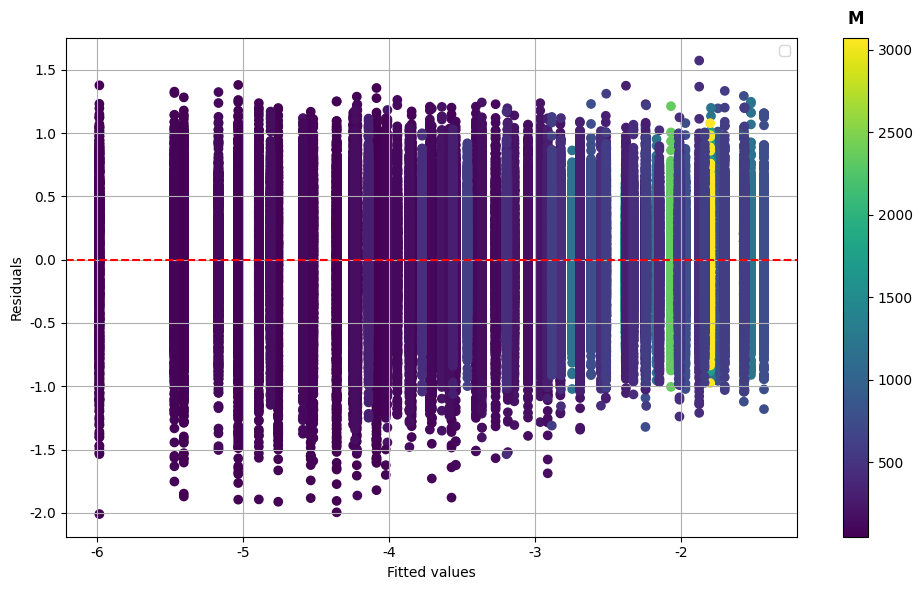

[6.4 4.8]


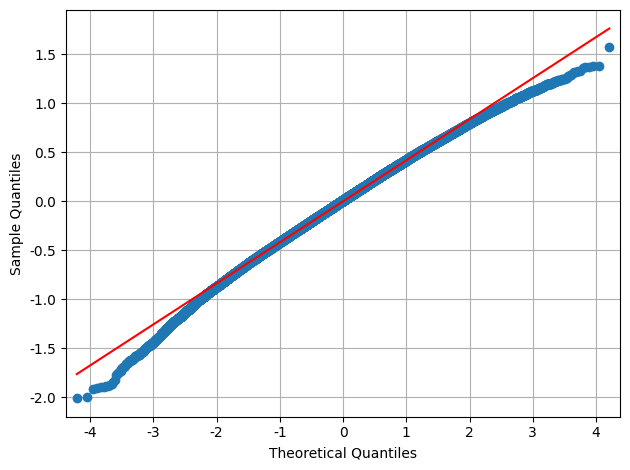

In [166]:
# Plot the residuals and values
plt.figure(figsize=(10, 6))
plt.scatter(results.fittedvalues, results.resid, c=df_errors_ols['M'], cmap='viridis')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')

# plt.title('Residuals vs Fitted values')

cbar = plt.colorbar()
cbar.ax.set_title('M', weight='bold', pad=10)
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

# Plot the QQ plot of the residuals
fig = sm.qqplot(results.resid, line='s')
print(fig.get_size_inches())
# plt.title('QQ plot of residuals')
plt.grid(True)
plt.tight_layout()
plt.show()

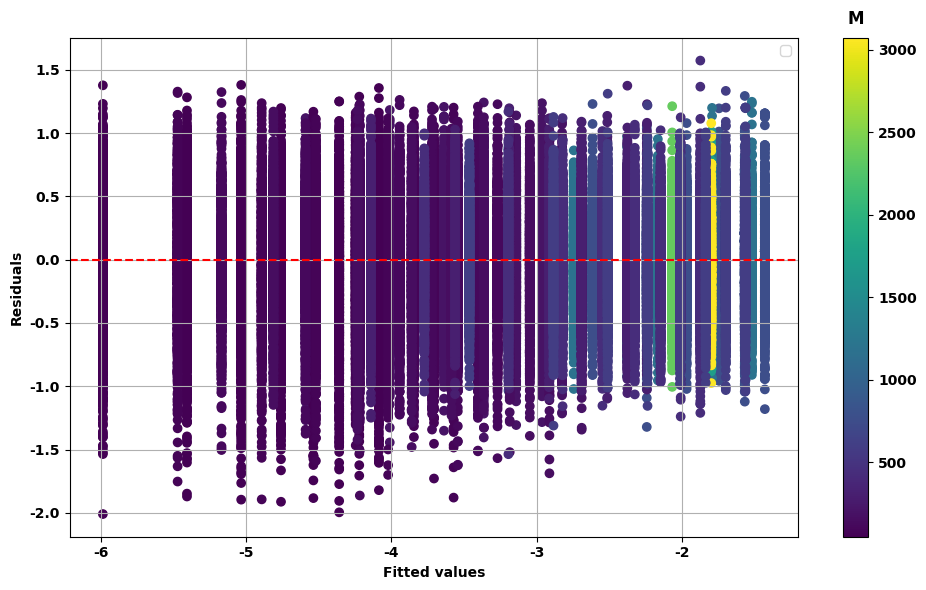

[6.4 4.8]


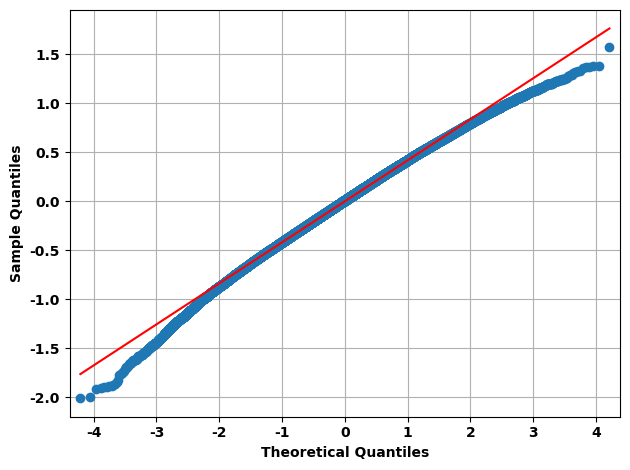

In [167]:
# Plot the residuals and values
plt.figure(figsize=(10, 6))
plt.scatter(results.fittedvalues, results.resid, c=df_errors_ols['M'], cmap='viridis')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values', weight='bold')
plt.ylabel('Residuals', weight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
# plt.title('Residuals vs Fitted values')

cbar = plt.colorbar()
cbar.ax.set_title('M', weight='bold', pad=10)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight('bold')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

# Plot the QQ plot of the residuals
fig = sm.qqplot(results.resid, line='s')
# Make axes label bold
fig.axes[0].set_xlabel('Theoretical Quantiles', weight='bold')
fig.axes[0].set_ylabel('Sample Quantiles', weight='bold')
print(fig.get_size_inches())
# plt.title('QQ plot of residuals')
plt.grid(True)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.tight_layout()
plt.show()

<Axes: xlabel='None', ylabel='xT_error_inf_norm'>

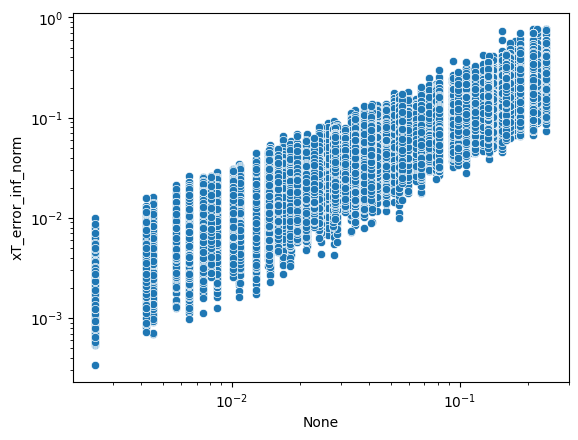

In [168]:
fig, ax =  plt.subplots(figsize=(6.4, 4.8))
ax.set(xscale='log', yscale='log')
sns.scatterplot(
    x=np.exp(results.fittedvalues),
    y=df_errors_ols['xT_error_inf_norm'],
    ax=ax,
)

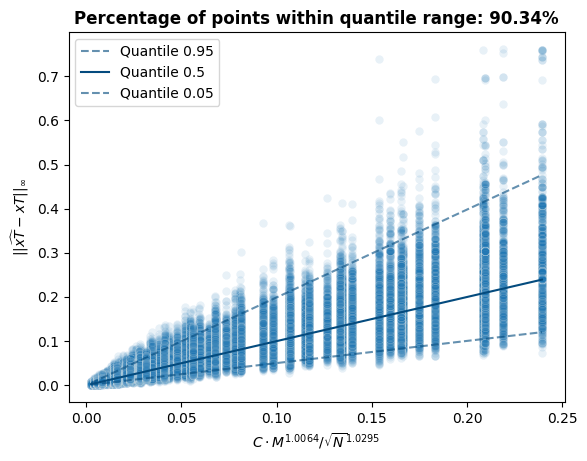

In [169]:
fig, ax = plt.subplots(figsize=(6.4, 4.8))

xs = np.exp(c)*df_errors_ols['M']**power * df_errors_ols['1/sqrt(N)']**beta

sns.scatterplot(
    x=xs,
    y=df_errors_ols['xT_error_inf_norm'],
    ax=ax,
    alpha=0.1,
)

# Add quantiles
quantiles = [0.05, 0.5, 0.95]
linestyles = ['--', '-', '--']
colors = ['blue', 'darkblue', 'blue']
colors = ["#044b7e9d", "#044b7e", '#044b7e9d']


xs_plot = np.linspace(xs.min(), xs.max(), 1000)
for i, q in enumerate(quantiles[::-1]):
    quantile = lognorm.ppf(q, s=std_residuals, scale=xs_plot)
    plt.plot(xs_plot, quantile, label=f'Quantile {q}', linestyle=linestyles[i], color=colors[i])

ax.set_xlabel(r'$C\cdot M^{%.4f} / \sqrt{N}^{%.4f}$' % (power, beta), weight='bold')
ax.set_ylabel(r'$||\widehat{xT} - xT||_{\infty}$', weight='bold')

# Calculate the number of points within the quantile range
within_quantile = df_errors_ols[
    (df_errors_ols['xT_error_inf_norm'] >= lognorm.ppf(0.05, s=std_residuals, scale=xs)) &
    (df_errors_ols['xT_error_inf_norm'] <= lognorm.ppf(0.95, s=std_residuals, scale=xs))
]

within_quantile_count = len(within_quantile)
plt.title(f'Percentage of points within quantile range: {within_quantile_count/len(xs)*100:.2f}%', weight='bold')
# Make it an annotation
# plt.annotate(
#     f'Percentage of points within quantile range: {within_quantile_count/len(xs)*100:.2f}%',
#     xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, ha='left', va='top',
#     bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='white')
# )

plt.legend()

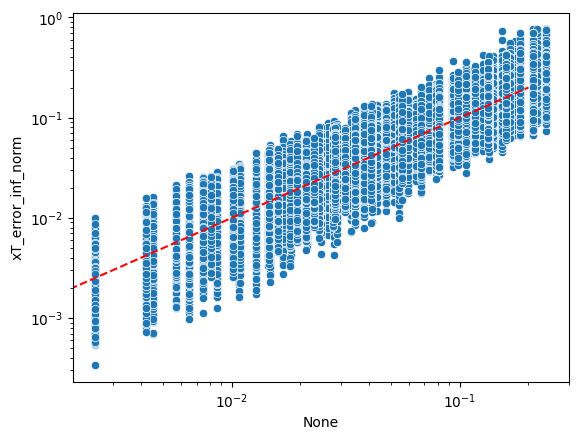

In [170]:
fig, ax =  plt.subplots(figsize=(6.4, 4.8))
ax.set(xscale='log', yscale='log')
sns.scatterplot(
    x=np.exp(results.fittedvalues),
    y=df_errors_ols['xT_error_inf_norm'],
    ax=ax,
)
# Add line y=x
plt.plot([0, 0.2], [0, 0.2], color='red', linestyle='--', label='y=x')

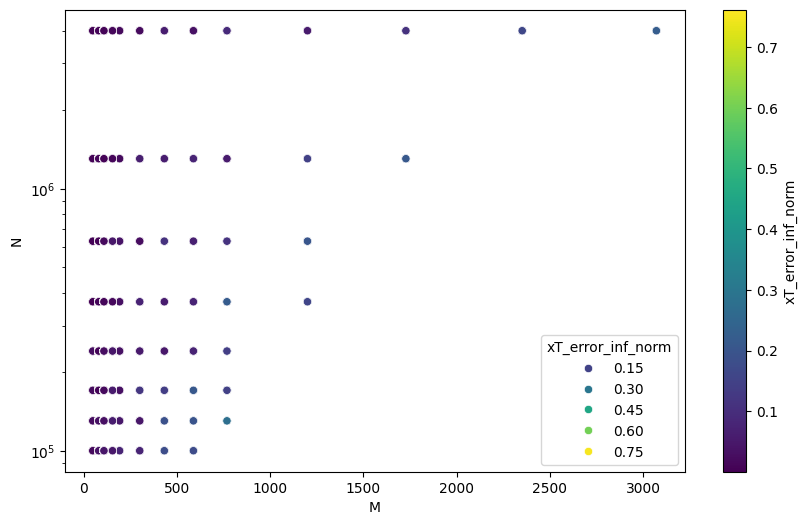

In [171]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x=df_errors_ols['M'], y=df_errors_ols['N'], hue=df_errors_ols['xT_error_inf_norm'], palette='viridis', ax=ax)


# Add a color bar
norm_ = plt.Normalize(df_errors_ols['xT_error_inf_norm'].min(), df_errors_ols['xT_error_inf_norm'].max())
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm_)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('xT_error_inf_norm')

ax.set_yscale('log')

plt.xlabel('M')
plt.ylabel('N')

plt.show()


C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_20360\1077566251.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


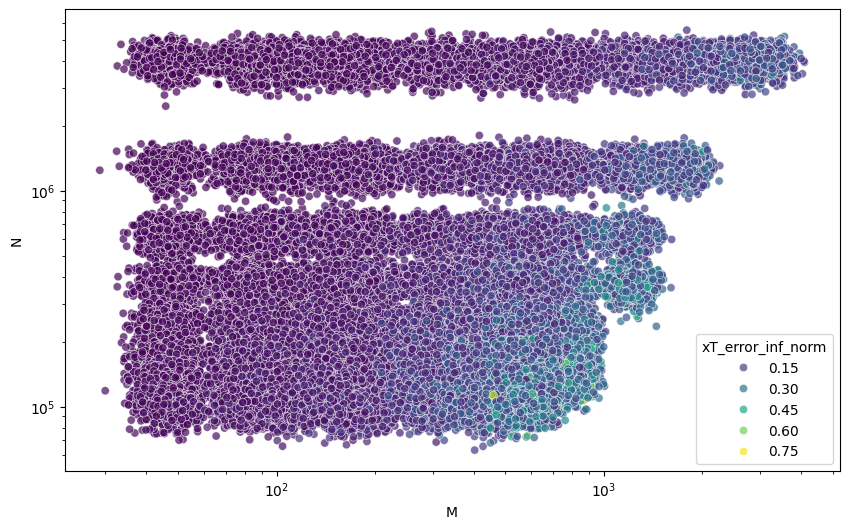

In [172]:
# Jittered version
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm

# Create a new figure
fig, ax = plt.subplots(figsize=(10, 6))
# Create a colormap
cmap = cm.get_cmap('viridis')
# Create a scatter plot with jitter
sns.scatterplot(
    x=df_errors_ols['M'] * (1+np.random.normal(0, 0.1, size=len(df_errors_ols))),
    y=df_errors_ols['N'] * (1+np.random.normal(0, 0.1, size=len(df_errors_ols))),
    hue=df_errors_ols['xT_error_inf_norm'],
    palette='viridis',
    alpha=0.7,
    edgecolor='w',
    ax=ax,
    legend=True
)

# Add a color bar
# norm_ = plt.Normalize(df_errors_ols['xT_error_inf_norm'].min(), df_errors_ols['xT_error_inf_norm'].max())
# sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm_)
# sm.set_array([])
# cbar = plt.colorbar(sm)
# cbar.set_label('xT_error_inf_norm')
plt.yscale('log')
plt.xscale('log')

plt.show()

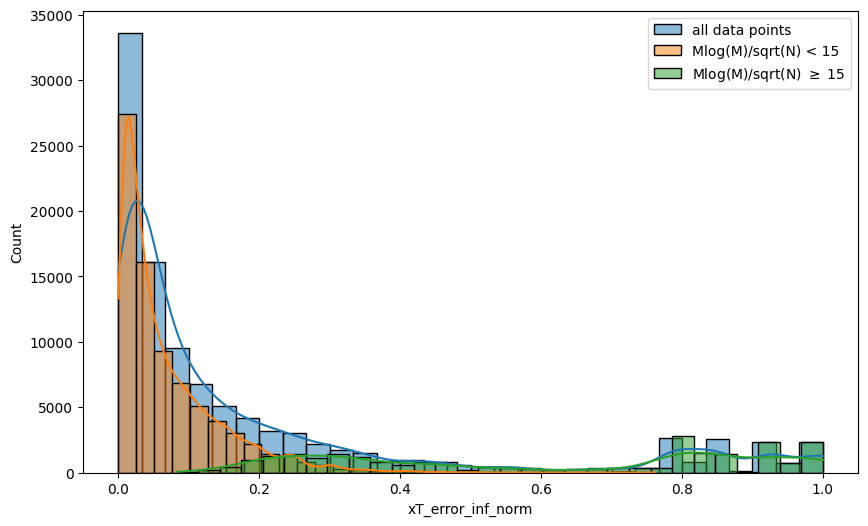

In [173]:
# Plot histogram of the errors. 
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df_errors['xT_error_inf_norm'], bins=30, kde=True, label='all data points', ax=ax)
sns.histplot(df_errors[df_errors['Mlog(M)/sqrt(N)'] < 15]['xT_error_inf_norm'], bins=30, kde=True, label='Mlog(M)/sqrt(N) < 15', ax=ax)
sns.histplot(df_errors[df_errors['Mlog(M)/sqrt(N)'] >= 15]['xT_error_inf_norm'], bins=30, kde=True, label=r'Mlog(M)/sqrt(N) $\geq$ 15', ax=ax)

plt.legend()



In [174]:
n_x = 16
3/4*n_x**2

192.0

In [175]:
np.sqrt(384/3*4)

np.float64(22.627416997969522)

In [176]:
768/192

4.0

In [177]:
4.0**0.9898

3.9438372025181434

In [178]:
3.9438372025181434**(2/1.0416)

13.93919429608591

In [179]:
4**(2*0.9898/1.0416)

13.939194296085912

In [180]:
10**(1.0416)

11.005252214205424

In [181]:
results.params

const            -2.054962
log(M)            1.006356
log(1/sqrt(N))    1.029492
dtype: float64

In [182]:
results.mse_resid

np.float64(0.17520784545125873)

In [183]:
np.sqrt(results.mse_resid)**2

np.float64(0.1752078454512587)

In [184]:
c = results.params['const']
power = results.params['log(M)']
std_residuals = np.sqrt(results.mse_resid)
beta = results.params['log(1/sqrt(N))']
print(f"c={c}")
print(f"power={power}")
print(f"std_residuals={std_residuals}")
print(f"beta={beta}")

c=-2.0549618693866707
power=1.006356015220525
std_residuals=0.41857836237825136
beta=1.0294922965295545


In [185]:
1.0416318444260435*-0.5

-0.5208159222130218

C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_20360\1870385978.py:4: RuntimeWarning: divide by zero encountered in log
  error_cdf = lambda t: norm.cdf(-c -power*np.log(M) + beta*np.log(np.sqrt(N)) + np.log(t), loc=0, scale=std_residuals)


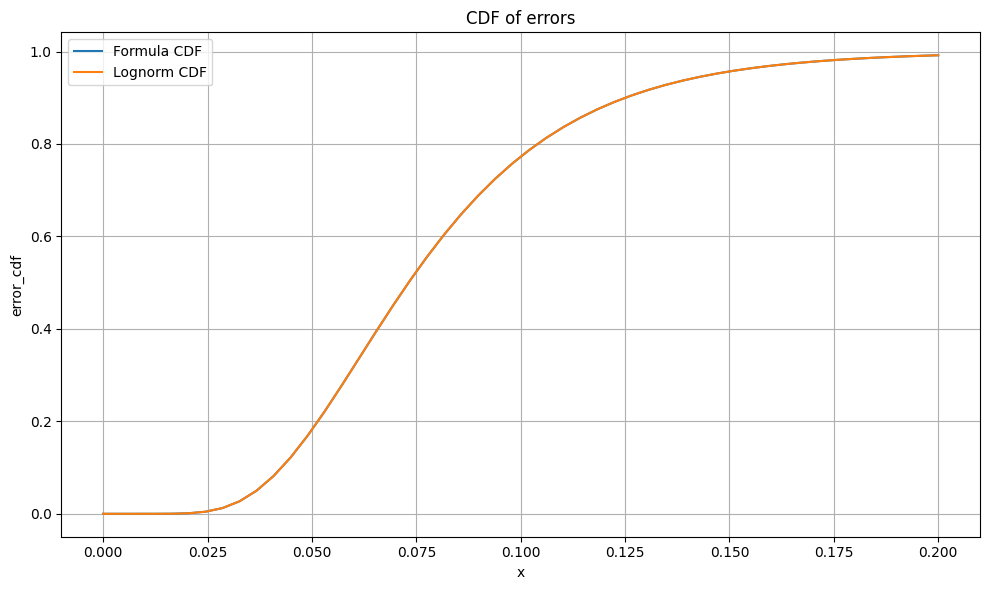

In [186]:
M = 768
N = 1300000

error_cdf = lambda t: norm.cdf(-c -power*np.log(M) + beta*np.log(np.sqrt(N)) + np.log(t), loc=0, scale=std_residuals)

# Plot the function error_cdf
x = np.linspace(0, 0.20)
y = error_cdf(x)
y_ = lognorm.cdf(x=x, s=std_residuals, scale=np.exp(c + power*np.log(M) - beta*np.log(np.sqrt(N))))
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Formula CDF')
plt.plot(x, y_, label='Lognorm CDF')
plt.legend()
plt.xlabel('x')
plt.ylabel('error_cdf')
plt.title('CDF of errors')
plt.grid(True)
plt.tight_layout()
plt.show()

In [187]:
print(df_errors_ols['M'].unique().tolist())
print(df_errors_ols['N'].unique().tolist())

[192, 768, 1200, 1728, 2352, 3072, 48, 80, 108, 154, 300, 432, 588]
[4000000, 1300000, 630000, 370000, 240000, 170000, 130000, 100000]


Text(0.5, 0, 'Error')

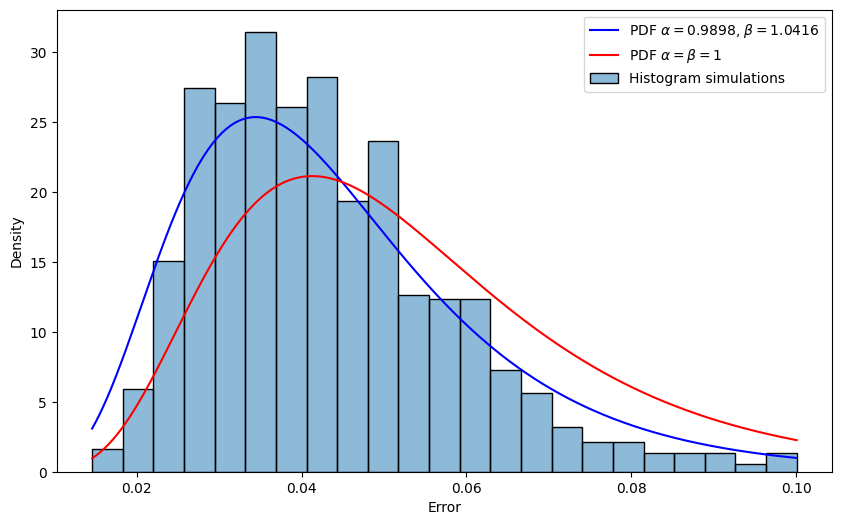

In [188]:
# M = 192
M = 768
N = 4000000


data = df_errors_ols[(df_errors_ols['M'] == M) & (df_errors_ols['N'] == N)]['xT_error_inf_norm'].values

fig, ax = plt.subplots(figsize=(10, 6))

# Plot histogram
sns.histplot(data, stat='density', bins='auto', kde=False, label='Histogram simulations', alpha=0.5, ax=ax)

# # Plot the kde
# sns.kdeplot(data, cumulative=False, label='KDE', color='orange', ax=ax)

# Plot fitted PDF
x = np.linspace(data.min(), data.max(), 1000)
y = lognorm.pdf(x=x, s=std_residuals, scale=np.exp(c + power*np.log(M) - beta*np.log(np.sqrt(N))))
ax.plot(x, y, label=r'PDF $\alpha=0.9898$, $\beta=1.0416$', color='blue')

y_ = lognorm.pdf(x=x, s=std_residuals, scale=np.exp(c + 1*np.log(M) - 1*np.log(np.sqrt(N))))
ax.plot(x, y_, label=r'PDF $\alpha=\beta=1$', color='red')

ax.legend()
plt.xlabel('Error')

In [189]:
from scipy.stats import kstest

distribution = lognorm(s=std_residuals, scale=np.exp(c + power*np.log(M) - beta*np.log(np.sqrt(N))))
print(kstest(data, distribution.cdf))

KstestResult(statistic=np.float64(0.05847567186766167), pvalue=np.float64(0.002053178324370514), statistic_location=np.float64(0.0610899557605282), statistic_sign=np.int8(1))


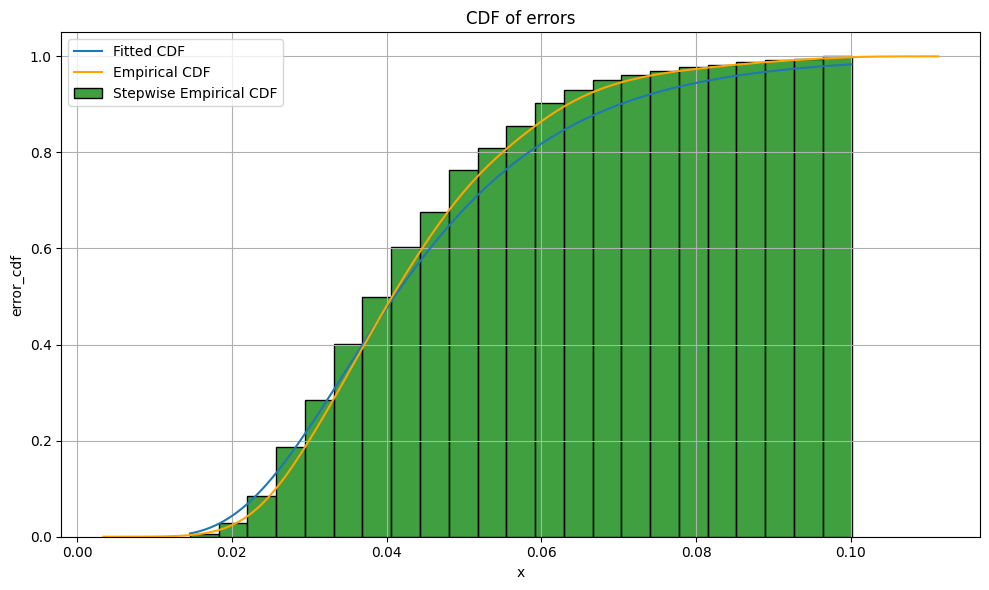

In [190]:
error_cdf = lambda t: norm.cdf(-c -power*np.log(M) + beta*np.log(np.sqrt(N)) + np.log(t), loc=0, scale=std_residuals)

data = df_errors_ols[(df_errors_ols['M'] == M) & (df_errors_ols['N'] == N)]['xT_error_inf_norm'].values

# Plot the function error_cdf
# x = np.linspace(0, 0.10)
y = error_cdf(x)
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Fitted CDF')

# Plot the emperical CDF
sns.kdeplot(data, cumulative=True, label='Empirical CDF', color='orange')

# Plot the stepwise emperical CDF
sns.histplot(data, cumulative=True, stat='density', bins='auto', kde=False, label='Stepwise Empirical CDF', color='green')

# Add legend
plt.legend()

plt.xlabel('x')
plt.ylabel('error_cdf')
plt.title('CDF of errors')
plt.grid(True)
plt.tight_layout()
plt.show()

In [191]:
print(f"power={power}")
print(f"beta={beta}")
print(f"std_residuals={std_residuals}")
print(f"c={c}")

power=1.006356015220525
beta=1.0294922965295545
std_residuals=0.41857836237825136
c=-2.0549618693866707


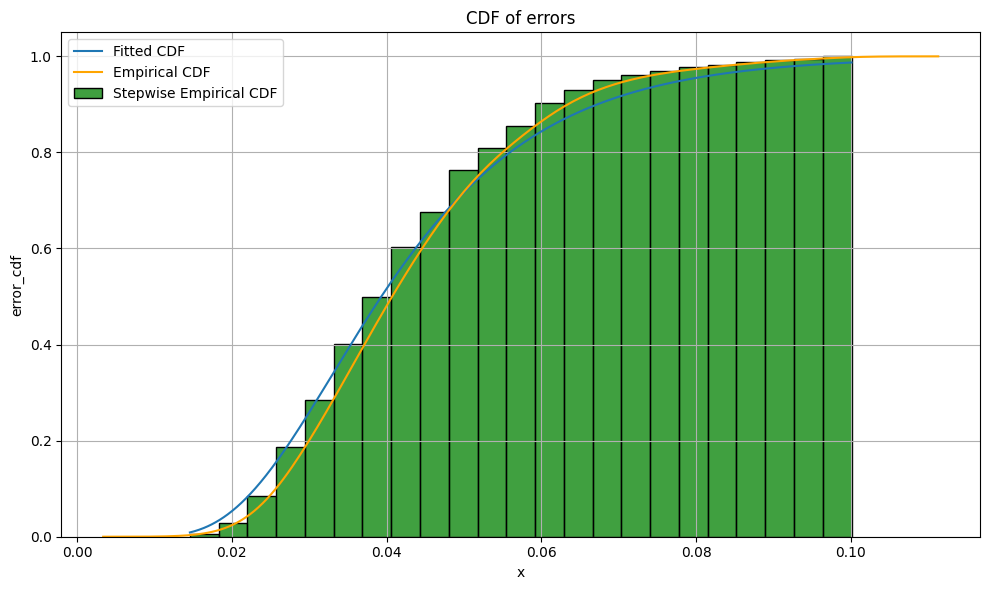

In [192]:
error_cdf = lambda t: norm.cdf(-c -1*np.log(M) + beta*np.log(np.sqrt(N)) + np.log(t), loc=0, scale=std_residuals)

data = df_errors_ols[(df_errors_ols['M'] == M) & (df_errors_ols['N'] == N)]['xT_error_inf_norm'].values

# Plot the function error_cdf
# x = np.linspace(0, 0.10)
y = error_cdf(x)
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Fitted CDF')

# Plot the emperical CDF
sns.kdeplot(data, cumulative=True, label='Empirical CDF', color='orange')

# Plot the stepwise emperical CDF
sns.histplot(data, cumulative=True, stat='density', bins='auto', kde=False, label='Stepwise Empirical CDF', color='green')

# Add legend
plt.legend()

plt.xlabel('x')
plt.ylabel('error_cdf')
plt.title('CDF of errors')
plt.grid(True)
plt.tight_layout()
plt.show()

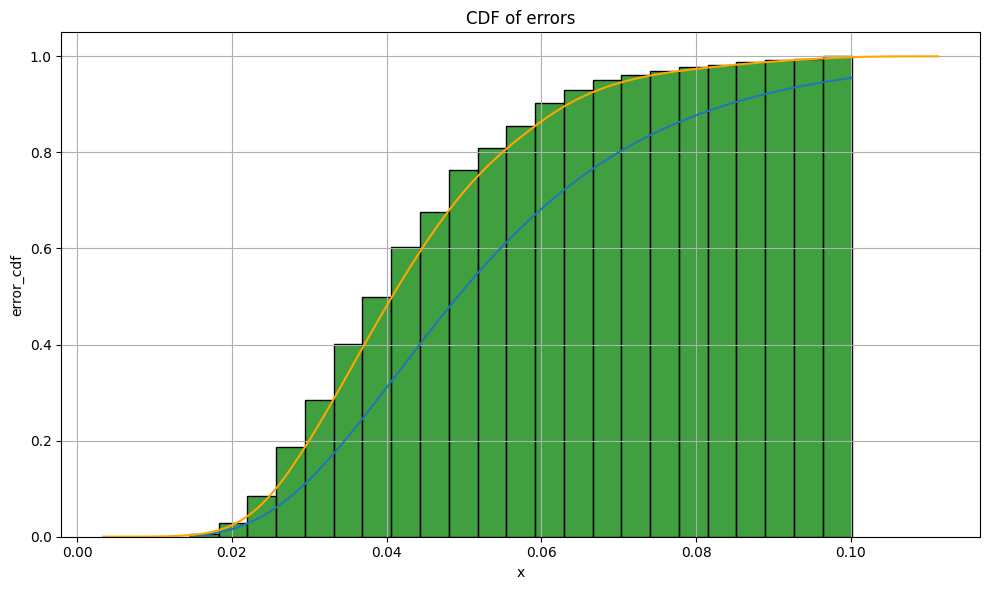

In [193]:
error_cdf = lambda t: norm.cdf(-c -1*np.log(M) + 1*np.log(np.sqrt(N)) + np.log(t), loc=0, scale=std_residuals)

data = df_errors_ols[(df_errors_ols['M'] == M) & (df_errors_ols['N'] == N)]['xT_error_inf_norm'].values

# Plot the function error_cdf
# x = np.linspace(0, 0.10)
y = error_cdf(x)
plt.figure(figsize=(10, 6))
plt.plot(x, y)

# Plot the emperical CDF
sns.kdeplot(data, cumulative=True, label='Empirical CDF', color='orange')

# Plot the stepwise emperical CDF
sns.histplot(data, cumulative=True, stat='density', bins='auto', kde=False, label='Stepwise Empirical CDF', color='green')

plt.xlabel('x')
plt.ylabel('error_cdf')
plt.title('CDF of errors')
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_20360\1218398574.py:4: RuntimeWarning: divide by zero encountered in log
  error_cdf = lambda t: norm.cdf(-c -0.9898277902846392*np.log(M) + 1.0416318444260435*np.log(np.sqrt(N)) + np.log(t), loc=0, scale=std_residuals)


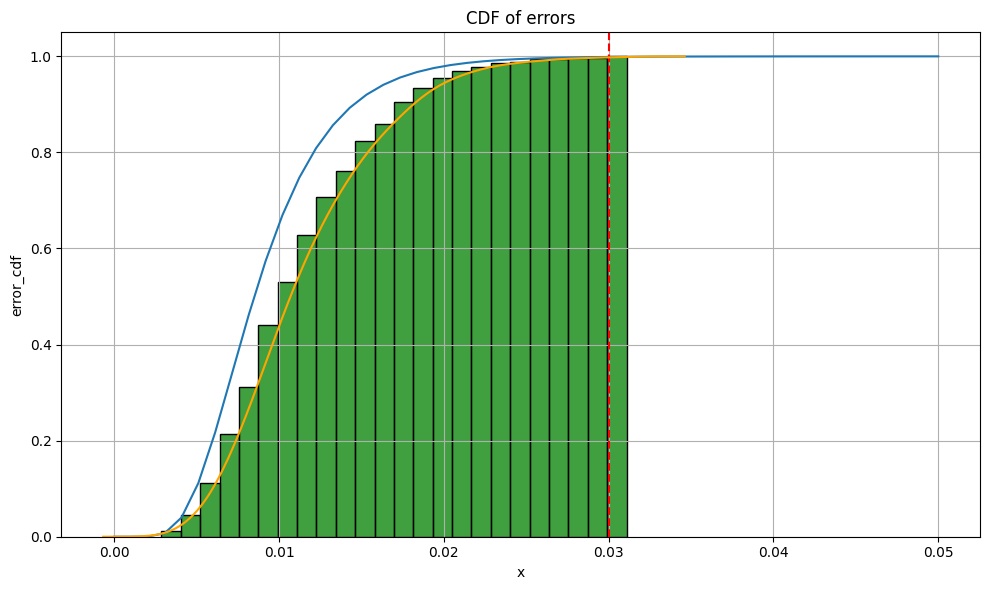

In [194]:
N = 4_000_000
M = 16*12

error_cdf = lambda t: norm.cdf(-c -0.9898277902846392*np.log(M) + 1.0416318444260435*np.log(np.sqrt(N)) + np.log(t), loc=0, scale=std_residuals)

data = df_errors_ols[(df_errors_ols['M'] == M) & (df_errors_ols['N'] == N)]['xT_error_inf_norm'].values

# Plot the function error_cdf
x = np.linspace(0, 0.050)
y = error_cdf(x)
plt.figure(figsize=(10, 6))
plt.plot(x, y)
# vertical line at 0.03
plt.axvline(x=0.03, color='red', linestyle='--', label='max_max_error')

# Plot the emperical CDF
sns.kdeplot(data, cumulative=True, label='Empirical CDF', color='orange')

# Plot the stepwise emperical CDF
sns.histplot(data, cumulative=True, stat='density', bins='auto', kde=False, label='Stepwise Empirical CDF', color='green')

plt.xlabel('x')
plt.ylabel('error_cdf')
plt.title('CDF of errors')
plt.grid(True)
plt.tight_layout()
plt.show()

## Investigate if log(M) should be kept in there

In [195]:
log_y = np.log(df_errors_ols['xT_error_inf_norm'])/np.log(df_errors_ols['M'])
log_x = np.log(df_errors_ols[f'log(M)/sqrt(N)'])
log_M = np.log(df_errors_ols['M'])

# Do OLS regression on log transformations

X = sm.add_constant(pd.DataFrame({
    # 'log(log(M))': np.log(np.log(df_errors_ols['M'])), 
    'log(M)': np.log(df_errors_ols['M']),
    'log(1/sqrt(N))': -np.log(np.sqrt(df_errors_ols['N']))
    }))
# X = sm.add_constant(np.array([log_x, log_M]).T)
Y = log_y
# Fit the model
model = sm.OLS(Y,X)
results = model.fit()
print(results.summary())

from sklearn.metrics import r2_score
print(f"R2 (rescaled): {r2_score(np.log(df_errors_ols['M']) * log_y, np.log(df_errors_ols['M']) * results.predict(X))}")

# Plot the residuals and values
plt.figure(figsize=(10, 6))
plt.scatter(results.fittedvalues, results.resid)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted values')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot the QQ plot of the residuals
sm.qqplot(results.resid, line='s')
plt.title('QQ plot of residuals')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot the residuals and values
plt.figure(figsize=(10, 6))
plt.scatter(np.log(df_errors_ols['M']) * results.fittedvalues, np.log(df_errors_ols['M']) * results.resid)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted values rescaled to original OLS scale')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot the QQ plot of the residuals
sm.qqplot(np.log(df_errors_ols['M']) * results.resid, line='s')
plt.title('QQ plot of residuals rescaled to original OLS scale')
plt.grid(True)
plt.tight_layout()
plt.show()

AttributeError: '_ScalarMappable' object has no attribute 'add_constant'

In [ ]:
c_log = results.params['const']
power_log = results.params['log(M)']
std_residuals_log = np.sqrt(results.mse_resid)
beta_log = results.params['log(1/sqrt(N))']
print(f"c={c_log}")
print(f"power={power_log}")
print(f"std_residuals={std_residuals_log}")
print(f"beta={beta_log}")

c=-0.7077742136492984
power=0.23520005516512252
std_residuals=0.062383227886882595
beta=0.18115674580021848


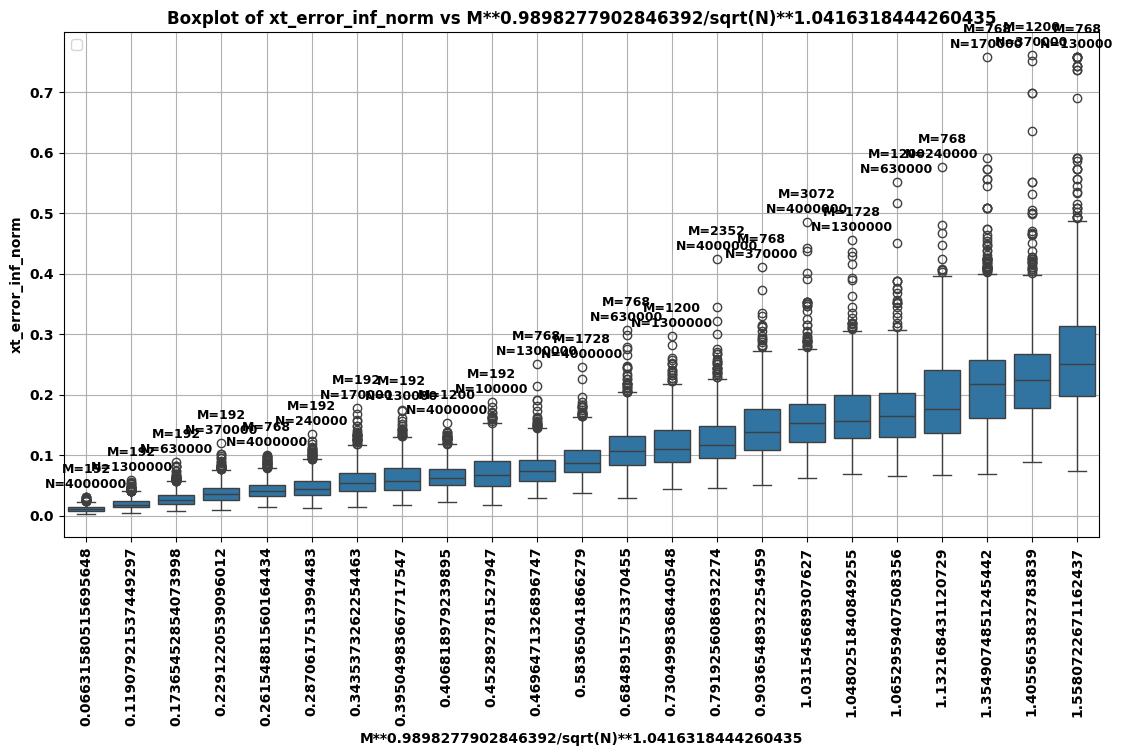

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_errors_ols[f'M**{power}/sqrt(N)**{beta}'] = df_errors_ols['M']**power * df_errors_ols['1/sqrt(N)']**beta

# Create the boxplot
plt.figure(figsize=(12, 6))
ax = sns.boxplot(x=f'M**{power}/sqrt(N)**{beta}', y='xT_error_inf_norm', data=df_errors_ols)

# Add a red dashed line for max_max_error
# plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')

# Set labels and title
plt.xlabel(f'M**{power}/sqrt(N)**{beta}')
plt.ylabel('xt_error_inf_norm')
plt.title(f'Boxplot of xt_error_inf_norm vs M**{power}/sqrt(N)**{beta}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=90)

# Annotate each box with M and N
grouped = df_errors_ols.groupby(f'M**{power}/sqrt(N)**{beta}')
for i, (name, group) in enumerate(grouped):
    # Use the first row as a representative for M and N
    M = group['M'].iloc[0]
    N = group['N'].iloc[0]
    ax.text(i, group['xT_error_inf_norm'].max() + 0.01, f'M={M}\nN={N}',
            ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.show()


1.5580722671162437
[0.     0.1875 0.375  0.5625 0.75   0.9375 1.125  1.3125 1.5   ]


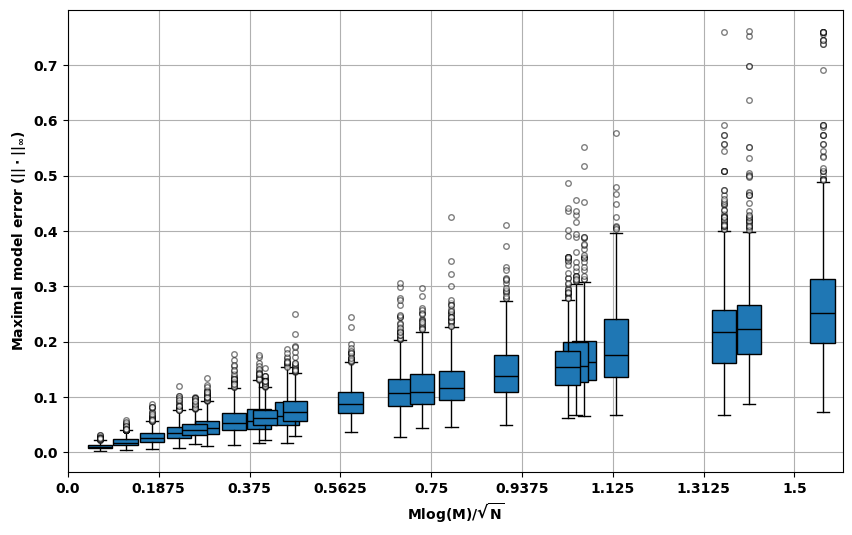

In [ ]:
plt.figure(figsize=(10, 6))

df_errors_ols[f'M**{power}/sqrt(N)**{beta}'] = df_errors_ols['M']**power * df_errors_ols['1/sqrt(N)']**beta

vals = df_errors_ols[f'M**{power}/sqrt(N)**{beta}'].unique().tolist()
data_listed = [
    df_errors_ols[df_errors_ols[f'M**{power}/sqrt(N)**{beta}'] == val]['xT_error_inf_norm'].tolist()
    for val in vals
]

for idx, (val, data_points) in enumerate(zip(vals, data_listed)):
    plt.boxplot(
        data_points,
        positions=[val],
        widths=0.05,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1),
        # boxprops=dict(facecolor='lightblue', color='black', linewidth=1),
        boxprops=dict(facecolor=color, color='black', linewidth=1),
        # boxprops=dict(facecolor='#4C72B0', color='black'),
        capprops=dict(color='black'),
        whiskerprops=dict(color='black'),
        flierprops=dict(markerfacecolor='white', marker='o', markersize=4, alpha=0.5),
        zorder=idx,
    )

plt.grid(True)
plt.xlim(0, 1.6)
n_ticks = 9
ticks = np.linspace(0.0, 1.5, n_ticks)
print(max(vals))
print(ticks)
plt.xticks(ticks, labels=ticks)
plt.xlabel(r'$Mlog(M)/\sqrt{N}$')
plt.ylabel(r'Maximal model error ($||\cdot||_{\infty}$)')
plt.show()